# Arctic Sea-Ice Freeboard Reconstruction Project

This notebook is written as an external-facing research deliverable.
It is organized to make each step explicit: **what this step does**, **how it is implemented**, and **why it matters for the next step**.

Reading flow:
1. Setup and reusable utilities
2. Data audit and exploratory diagnostics
3. Controlled interpolation experiments (trajectory-wise and spatial-field)
4. Feature recoverability analysis
5. Environmental trade-off assessment and export

## Background and Motivation

Sea-ice freeboard observations are sparse and unevenly distributed across space and time.
This creates two practical needs:
- reconstruct missing values reliably,
- preserve structures that matter physically (not just smooth the field).

In this notebook, model quality is evaluated from both prediction and scientific-interpretability angles, then connected to computational sustainability.

## Problem Statement and Objectives

This study evaluates interpolation behavior in two complementary settings:
1. **Trajectory-wise reconstruction** on satellite tracks.
2. **Spatial-field reconstruction** on irregular spatial samples.

Objectives:
- build a reproducible end-to-end pipeline,
- compare interpolation families under controlled data-loss settings,
- provide rich diagnostics to explain model behavior,
- quantify spatial/temporal feature recoverability,
- report runtime, energy, and carbon alongside prediction metrics.

## Methodology Overview

Pipeline logic:
1. **Audit input data quality** (coverage, composition, distributions, footprint).
2. **Run trajectory-wise experiments** with consistent missing-data ratios.
3. **Run spatial-field experiments** with comparable stress tests.
4. **Evaluate feature recoverability** against sparse references.
5. **Aggregate performance and environmental cost** for evidence-based methodological conclusions.

This structure ensures each later section is grounded by earlier evidence.

## Reproducibility and Runtime Notes

Execution assumptions:
- Input data under `final/project/data/`.
- Outputs written to `final/project/outputs/`.
- Fixed random seed for stable split behavior.
- GP subset caps are intentionally used in large spatial runs to keep runtime practical while preserving comparative insight.

### Setup and Paths

This step initializes the execution environment used by the rest of the notebook.

- What is done: imports scientific libraries, sets a fixed random seed, and defines input/output paths.
- How it is done: creates `data/`, `outputs/figures`, `outputs/tables`, and `outputs/metrics` contracts through path variables.
- Why it matters next: every downstream cell reads from these paths and writes artifacts through the same structure, which keeps the workflow reproducible and reviewable.

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from scipy.ndimage import gaussian_filter, maximum_filter
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.neighbors import KNeighborsRegressor

SEED = 42
rng = np.random.default_rng(SEED)

PROJECT_DIR = Path.cwd().resolve().parent
DATA_DIR = PROJECT_DIR / 'data'
OUT_DIR = PROJECT_DIR / 'outputs'
FIG_DIR = OUT_DIR / 'figures'
TAB_DIR = OUT_DIR / 'tables'
MET_DIR = OUT_DIR / 'metrics'
for p in [FIG_DIR, TAB_DIR, MET_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print('PROJECT_DIR =', PROJECT_DIR)
print('DATA_DIR =', DATA_DIR)

from IPython.display import Image, display


PROJECT_DIR = /home/developer/ubuntu/project/ai/final/project
DATA_DIR = /home/developer/ubuntu/project/ai/final/project/data


### Shared Metrics and Accounting Functions

This step defines reusable functions so evaluation remains consistent across all experiments.

- What is done: regression metrics (RMSE/MAE/R2), compute-to-carbon estimation, and spectral-band helper functions.
- How it is done: all methods call the same utility functions rather than redefining logic per section.
- Why it matters next: trajectory and spatial experiments become directly comparable, and environmental accounting stays uniform.

In [2]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_pred - y_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))
    denom = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = float(1.0 - np.sum(err * err) / denom) if denom > 0 else float('nan')
    return {'mae': mae, 'rmse': rmse, 'r2': r2}


def estimate_environment_cost(runtime_seconds, avg_power_watts=45.0, pue=1.2, carbon_intensity_g_per_kwh=475.0):
    energy_kwh = runtime_seconds * avg_power_watts * pue / (1000.0 * 3600.0)
    carbon_kg = energy_kwh * carbon_intensity_g_per_kwh / 1000.0
    return {
        'runtime_seconds': float(runtime_seconds),
        'avg_power_watts': float(avg_power_watts),
        'pue': float(pue),
        'carbon_intensity_g_per_kwh': float(carbon_intensity_g_per_kwh),
        'energy_kwh': float(energy_kwh),
        'carbon_kg_co2e': float(carbon_kg),
    }


def radial_band_power(arr2d, low=0.08, high=0.28):
    a = np.asarray(arr2d, dtype=float)
    a = np.nan_to_num(a - np.nanmean(a), nan=0.0)
    F = np.fft.fftshift(np.fft.fft2(a))
    P = np.abs(F) ** 2
    ny, nx = a.shape
    yy, xx = np.indices((ny, nx))
    cy, cx = ny // 2, nx // 2
    rr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    rr = rr / rr.max()
    m = (rr >= low) & (rr <= high)
    return float(P[m].mean()) if np.any(m) else float('nan')


def display_png(path: Path, width: int = 920):
    path = Path(path)
    if path.exists():
        print(f"[PNG] {path}")
        display(Image(filename=str(path), width=width))
    else:
        print(f"[PNG missing] {path}")


def display_csv_preview(path: Path, max_rows: int = 20):
    path = Path(path)
    if not path.exists():
        print(f"[CSV missing] {path}")
        return
    df = pd.read_csv(path)
    print(f"[CSV] {path} | rows={len(df)} cols={len(df.columns)}")
    if len(df) > max_rows:
        print(f"Showing first {max_rows} rows (table is larger).")
        display(df.head(max_rows))
    else:
        display(df)


## Data Loading and Initial Audit

This project uses **processed analysis-ready tables derived from raw satellite altimetry observations** (not raw L1/L2 image scenes).

### Original observation source (raw-data origin)
- Arctic satellite altimetry observations from:
  - **Sentinel-3A / Sentinel-3B (SRAL)**
  - **CryoSat-2**
- Variables represent geolocated surface/freeboard-related measurements over sea ice and leads.

### Analysis-ready files used in this notebook
- `df_GPOD.csv`:
  - point-based observation table (coordinates, time/date, platform, class label, freeboard/elevation proxy)
- `gridded_freeboard_arctic.h5:/preds`:
  - gridded prediction table with mean and variance fields for spatial reconstruction analysis
- `GPSat_alongtrack_Freeboard.h5`:
  - along-track dataset retained for traceability

### What was already done before this notebook
- coordinate/time harmonization
- schema standardization across platforms
- quality-control filtering of invalid records
- export to tabular CSV/HDF files for analysis

### What this notebook additionally does
- analysis-specific column selection
- key-null filtering required by interpolation models
- reproducible train/test masking for controlled missing-data experiments

This separation makes provenance explicit: heavy preprocessing is upstream; this notebook focuses on scientific evaluation and comparison.

### Data Ingestion and Audit Table

This step loads the two core datasets and establishes an auditable data snapshot.

- What is done: reads tabular observations and gridded prediction records, then exports a compact overview table.
- How it is done: selected columns are loaded explicitly and missing critical fields are filtered.
- Why it matters next: model comparisons are grounded in known input scope rather than implicit assumptions.

In [3]:
gpod_cols = ['x', 'y', 't', 'lon', 'lat', 'date', 'class', 'elevation', 'SAT', 'track']
df_gpod = pd.read_csv(DATA_DIR / 'df_GPOD.csv', usecols=gpod_cols)
df_gpod = df_gpod.dropna(subset=['x', 'y', 't', 'elevation'])

preds = pd.read_hdf(DATA_DIR / 'gridded_freeboard_arctic.h5', '/preds')
preds = preds[['f*', 'f*_var', 'pred_loc_x', 'pred_loc_y', 'pred_loc_t']].dropna()

overview = pd.DataFrame([
    {
        'dataset': 'df_GPOD.csv',
        'rows': len(df_gpod),
        'date_or_t_count': int(df_gpod['date'].nunique()),
        'sat_count': int(df_gpod['SAT'].nunique()),
        'track_count': int(df_gpod['track'].nunique()),
    },
    {
        'dataset': 'gridded_freeboard_arctic.h5:/preds',
        'rows': len(preds),
        'date_or_t_count': int(preds['pred_loc_t'].nunique()),
        'sat_count': 0,
        'track_count': 0,
    },
])
overview.to_csv(TAB_DIR / 'data_overview.csv', index=False)
overview


display_csv_preview(TAB_DIR / 'data_overview.csv')


[CSV] /home/developer/ubuntu/project/ai/final/project/outputs/tables/data_overview.csv | rows=2 cols=5


,dataset,rows,date_or_t_count,sat_count,track_count
0,df_GPOD.csv,1490258,9,3,652
1,gridded_freeboard_arctic.h5:/preds,1450984,1,0,0


### Data Source, Format, and Schema Notes

**Input files used in this notebook**
- `df_GPOD.csv`: tabular point observations with coordinates, acquisition date/platform, class label, and freeboard/elevation proxy.
- `gridded_freeboard_arctic.h5:/preds`: HDF table of gridded prediction outputs, including prediction mean and variance at spatial coordinates.

**What this cell does next**
- Builds a compact provenance table (path, format, size, role in analysis).
- Produces schema summaries (dtype + missing rate) for each dataset.
- Exports these tables for reproducibility and reviewer inspection.

### Data Source, Format, and Schema Documentation

This section makes provenance explicit for external readers.

- **Raw-data origin:** Arctic altimetry observations from Sentinel-3A/3B and CryoSat-2.
- **Files used here:** processed CSV/HDF analysis tables prepared from those observations.
- **Boundary of responsibility in this notebook:** light cleaning + experiment setup (not primary sensor preprocessing).

Exported documentation:
- `outputs/tables/data_source_and_format.csv`
- `outputs/tables/data_schema_summary.csv`

These files answer:
1. What original observation system does the data come from?
2. What processed files are analyzed here?
3. What processing happened upstream vs inside this notebook?

In [4]:
source_table = pd.DataFrame([
    {
        'dataset': 'df_GPOD.csv',
        'path': str(DATA_DIR / 'df_GPOD.csv'),
        'file_format': 'CSV',
        'size_mb': round((DATA_DIR / 'df_GPOD.csv').stat().st_size / 1024 / 1024, 2),
        'used_for': 'trajectory-wise reconstruction + EDA',
        'provenance': 'processed from Sentinel-3A/3B and CryoSat-2 Arctic altimetry observations',
        'upstream_preprocessing': 'coordinate/time harmonization, schema standardization, QC filtering',
        'primary_fields': 'x,y,t,lon,lat,date,SAT,track,class,elevation',
    },
    {
        'dataset': 'gridded_freeboard_arctic.h5:/preds',
        'path': str(DATA_DIR / 'gridded_freeboard_arctic.h5'),
        'file_format': 'HDF5 table',
        'size_mb': round((DATA_DIR / 'gridded_freeboard_arctic.h5').stat().st_size / 1024 / 1024, 2),
        'used_for': 'spatial-field reconstruction + recoverability analysis',
        'provenance': 'processed from Sentinel-3A/3B and CryoSat-2 Arctic altimetry observations',
        'upstream_preprocessing': 'spatial prediction gridding and uncertainty-field export',
        'primary_fields': 'f*,f*_var,pred_loc_x,pred_loc_y,pred_loc_t',
    },
])
source_table['notebook_processing_scope'] = 'column selection + key-null filtering + experiment split'
source_table.to_csv(TAB_DIR / 'data_source_and_format.csv', index=False)

schema_gpod = pd.DataFrame({
    'column': df_gpod.columns,
    'dtype': [str(df_gpod[c].dtype) for c in df_gpod.columns],
    'missing_rate': [float(df_gpod[c].isna().mean()) for c in df_gpod.columns],
    'dataset': 'df_GPOD.csv',
})

schema_preds = pd.DataFrame({
    'column': preds.columns,
    'dtype': [str(preds[c].dtype) for c in preds.columns],
    'missing_rate': [float(preds[c].isna().mean()) for c in preds.columns],
    'dataset': 'gridded_freeboard_arctic.h5:/preds',
})

schema_table = pd.concat([schema_gpod, schema_preds], ignore_index=True)
schema_table.to_csv(TAB_DIR / 'data_schema_summary.csv', index=False)

sample_gpod = df_gpod.head(5).copy()
sample_preds = preds.head(5).copy()

print('Data source table saved to:', TAB_DIR / 'data_source_and_format.csv')
print('Schema table saved to:', TAB_DIR / 'data_schema_summary.csv')
print('\nSource / format overview:')
display(source_table)
print('\nSample rows: df_GPOD.csv')
display(sample_gpod)
print('Sample rows: gridded_freeboard_arctic.h5:/preds')
display(sample_preds)


display_csv_preview(TAB_DIR / 'data_source_and_format.csv')
display_csv_preview(TAB_DIR / 'data_schema_summary.csv')


Data source table saved to: /home/developer/ubuntu/project/ai/final/project/outputs/tables/data_source_and_format.csv
Schema table saved to: /home/developer/ubuntu/project/ai/final/project/outputs/tables/data_schema_summary.csv

Source / format overview:


,dataset,path,file_format,size_mb,used_for,provenance,upstream_preprocessing,primary_fields,notebook_processing_scope
0,df_GPOD.csv,/home/developer/ubuntu/project/ai/final/projec...,CSV,169.89,trajectory-wise reconstruction + EDA,processed from Sentinel-3A/3B and CryoSat-2 Ar...,"coordinate/time harmonization, schema standard...","x,y,t,lon,lat,date,SAT,track,class,elevation",column selection + key-null filtering + experi...
1,gridded_freeboard_arctic.h5:/preds,/home/developer/ubuntu/project/ai/final/projec...,HDF5 table,142.72,spatial-field reconstruction + recoverability ...,processed from Sentinel-3A/3B and CryoSat-2 Ar...,spatial prediction gridding and uncertainty-fi...,"f*,f*_var,pred_loc_x,pred_loc_y,pred_loc_t",column selection + key-null filtering + experi...



Sample rows: df_GPOD.csv


,x,y,t,lon,lat,date,class,elevation,SAT,track
0,-3.056178e+06,-1.270463e+06,17907,-67.427184,60.000844,20190111,lead,0.4397,S3A,0
1,-3.055943e+06,-1.270243e+06,17907,-67.429148,60.003653,20190111,lead,0.4250,S3A,0
2,-3.055707e+06,-1.270022e+06,17907,-67.431112,60.006463,20190111,lead,0.4296,S3A,0
3,-3.055472e+06,-1.269801e+06,17907,-67.433077,60.009272,20190111,lead,0.4494,S3A,0
4,-3.055236e+06,-1.269580e+06,17907,-67.435042,60.012081,20190111,lead,0.4171,S3A,0


Sample rows: gridded_freeboard_arctic.h5:/preds


f*    f*_var  pred_loc_x  pred_loc_y  \
x          y          t                                                     
-1000000.0 -2200000.0 17910.0  0.171645  0.001504   -977500.0  -2087500.0   
                      17910.0  0.171652  0.001535   -977500.0  -2082500.0   
                      17910.0  0.171667  0.001451   -972500.0  -2097500.0   
                      17910.0  0.171738  0.001477   -972500.0  -2092500.0   
                      17910.0  0.171777  0.001504   -972500.0  -2087500.0   

                               pred_loc_t  
x          y          t                    
-1000000.0 -2200000.0 17910.0     17910.0  
                      17910.0     17910.0  
                      17910.0     17910.0  
                      17910.0     17910.0  
                      17910.0     17910.0

[CSV] /home/developer/ubuntu/project/ai/final/project/outputs/tables/data_source_and_format.csv | rows=2 cols=9


,dataset,path,file_format,size_mb,used_for,provenance,upstream_preprocessing,primary_fields,notebook_processing_scope
0,df_GPOD.csv,/home/developer/ubuntu/project/ai/final/projec...,CSV,169.89,trajectory-wise reconstruction + EDA,processed from Sentinel-3A/3B and CryoSat-2 Ar...,"coordinate/time harmonization, schema standard...","x,y,t,lon,lat,date,SAT,track,class,elevation",column selection + key-null filtering + experi...
1,gridded_freeboard_arctic.h5:/preds,/home/developer/ubuntu/project/ai/final/projec...,HDF5 table,142.72,spatial-field reconstruction + recoverability ...,processed from Sentinel-3A/3B and CryoSat-2 Ar...,spatial prediction gridding and uncertainty-fi...,"f*,f*_var,pred_loc_x,pred_loc_y,pred_loc_t",column selection + key-null filtering + experi...


[CSV] /home/developer/ubuntu/project/ai/final/project/outputs/tables/data_schema_summary.csv | rows=15 cols=4


,column,dtype,missing_rate,dataset
0,x,float64,0.0,df_GPOD.csv
1,y,float64,0.0,df_GPOD.csv
2,t,int64,0.0,df_GPOD.csv
3,lon,float64,0.0,df_GPOD.csv
4,lat,float64,0.0,df_GPOD.csv
5,date,int64,0.0,df_GPOD.csv
6,class,object,0.0,df_GPOD.csv
7,elevation,float64,0.0,df_GPOD.csv
8,SAT,object,0.0,df_GPOD.csv
9,track,int64,0.0,df_GPOD.csv


## Data Understanding and Visual Diagnostics

Before interpolation, we inspect data behavior from multiple angles:
- temporal/platform coverage,
- class composition,
- value distributions,
- spatial footprint.

These diagnostics explain where interpolation is likely to be stable or challenging, and they motivate the experimental matrix that follows.

### Exploratory Diagnostics: Coverage, Composition, and Footprint

This step builds the visual context needed before any interpolation claims.

- What is done: platform-date coverage heatmap, class composition chart, value distributions, and spatial footprint plots.
- How it is done: sampled visual diagnostics are exported for traceability and later discussion.
- Why it matters next: these diagnostics explain where interpolation is likely robust versus fragile.

Saved data visual diagnostics to outputs/figures and outputs/tables.
[PNG] /home/developer/ubuntu/project/ai/final/project/outputs/figures/data_sat_date_coverage.png


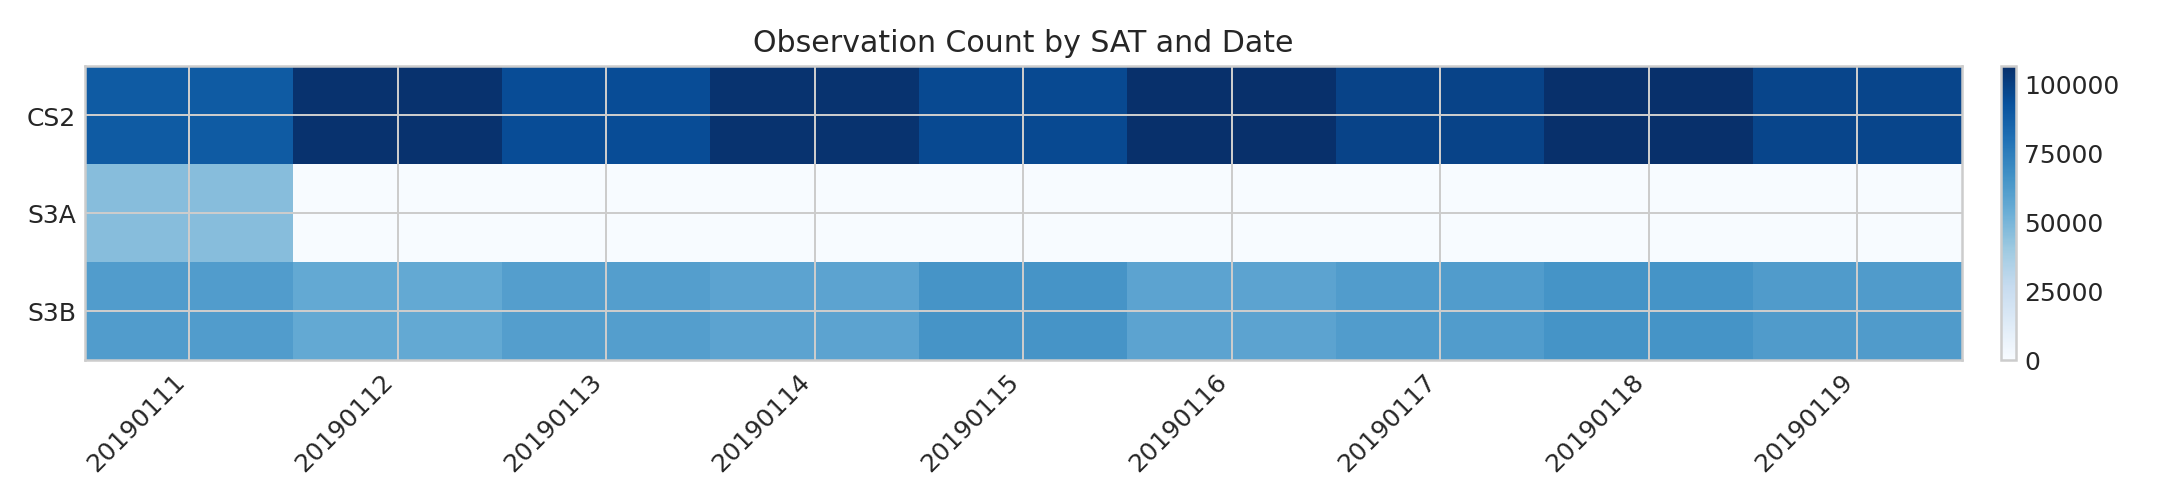

[PNG] /home/developer/ubuntu/project/ai/final/project/outputs/figures/data_class_composition.png


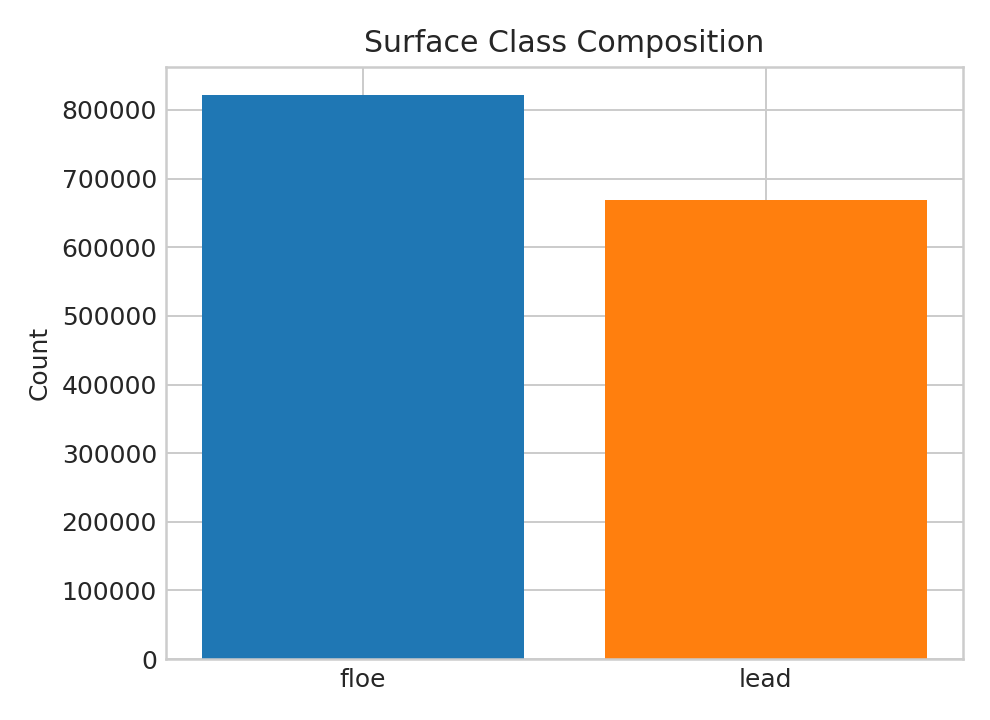

[PNG] /home/developer/ubuntu/project/ai/final/project/outputs/figures/data_elevation_distribution_by_sat.png


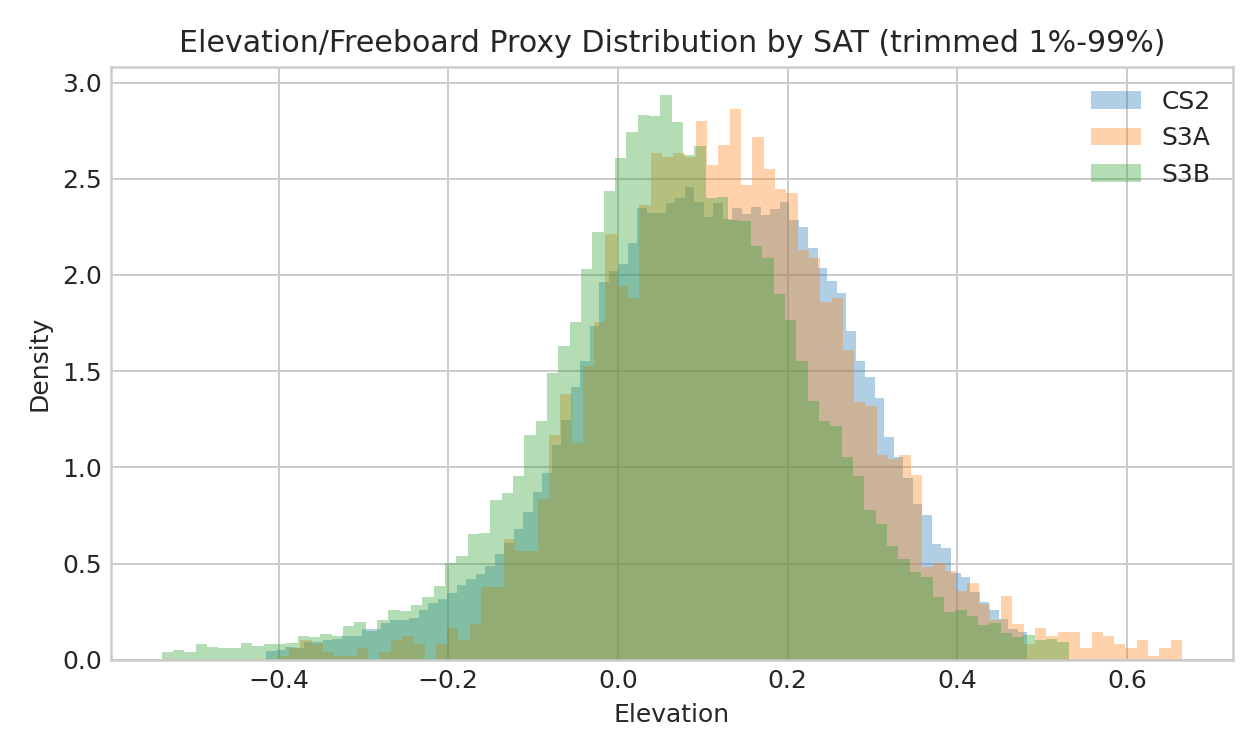

[PNG] /home/developer/ubuntu/project/ai/final/project/outputs/figures/data_spatial_footprints.png


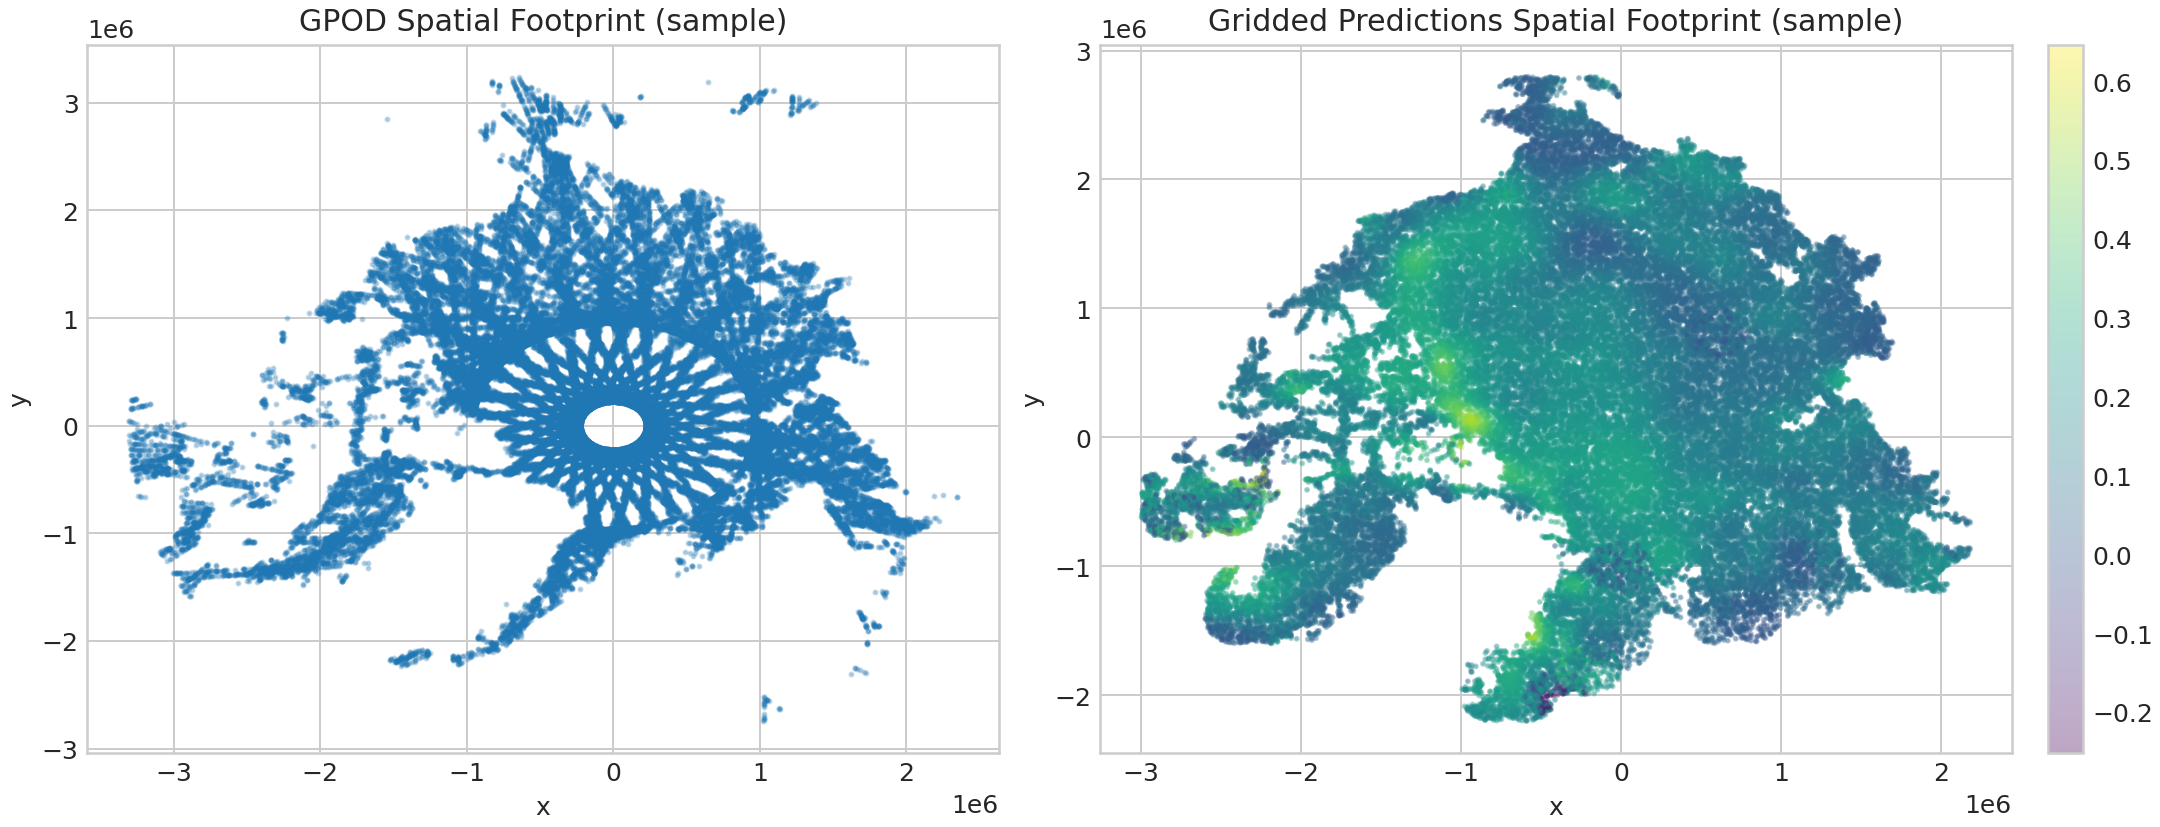

[CSV] /home/developer/ubuntu/project/ai/final/project/outputs/tables/sat_date_coverage_table.csv | rows=3 cols=10


,SAT,20190111,20190112,20190113,20190114,20190115,20190116,20190117,20190118,20190119
0,CS2,88718.0,105440.0,94442.0,104893.0,95720.0,106182.0,98458.0,106440.0,97491.0
1,S3A,46030.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,S3B,61317.0,55494.0,60329.0,58199.0,64895.0,57835.0,61258.0,65454.0,61663.0


In [5]:
# 1) SAT-date coverage heatmap table
sat_date = (
    df_gpod.groupby(['SAT', 'date'])
    .size()
    .reset_index(name='count')
)
pivot_cov = sat_date.pivot(index='SAT', columns='date', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(12, 2.8))
im = ax.imshow(pivot_cov.values, aspect='auto', cmap='Blues')
ax.set_title('Observation Count by SAT and Date')
ax.set_yticks(range(len(pivot_cov.index)))
ax.set_yticklabels(pivot_cov.index)
step = max(1, pivot_cov.shape[1] // 10)
ax.set_xticks(range(0, pivot_cov.shape[1], step))
ax.set_xticklabels([str(c) for c in pivot_cov.columns[::step]], rotation=45, ha='right')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'data_sat_date_coverage.png', dpi=180)
plt.close(fig)

# 2) Class composition
class_counts = df_gpod['class'].fillna('unknown').value_counts()
fig, ax = plt.subplots(figsize=(5.5, 4.0))
ax.bar(class_counts.index.astype(str), class_counts.values, color=['tab:blue', 'tab:orange', 'tab:gray'][:len(class_counts)])
ax.set_title('Surface Class Composition')
ax.set_ylabel('Count')
fig.tight_layout()
fig.savefig(FIG_DIR / 'data_class_composition.png', dpi=180)
plt.close(fig)

# 3) Elevation distribution by SAT (sampled for speed)
sample_dist = df_gpod[['SAT', 'elevation']].dropna().sample(min(120000, len(df_gpod)), random_state=SEED)
fig, ax = plt.subplots(figsize=(7, 4.2))
for sat, grp in sample_dist.groupby('SAT'):
    vals = grp['elevation'].to_numpy(float)
    q1, q99 = np.percentile(vals, [1, 99])
    vals = vals[(vals >= q1) & (vals <= q99)]
    ax.hist(vals, bins=80, alpha=0.35, density=True, label=sat)
ax.set_title('Elevation/Freeboard Proxy Distribution by SAT (trimmed 1%-99%)')
ax.set_xlabel('Elevation')
ax.set_ylabel('Density')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'data_elevation_distribution_by_sat.png', dpi=180)
plt.close(fig)

# 4) Spatial footprint samples
s1 = df_gpod.sample(min(60000, len(df_gpod)), random_state=SEED)
s2 = preds.sample(min(60000, len(preds)), random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
axes[0].scatter(s1['x'], s1['y'], s=2, alpha=0.25)
axes[0].set_title('GPOD Spatial Footprint (sample)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
sc = axes[1].scatter(s2['pred_loc_x'], s2['pred_loc_y'], c=s2['f*'], s=2, alpha=0.35, cmap='viridis')
axes[1].set_title('Gridded Predictions Spatial Footprint (sample)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.colorbar(sc, ax=axes[1], fraction=0.046, pad=0.04)
fig.savefig(FIG_DIR / 'data_spatial_footprints.png', dpi=180)
plt.close(fig)

# save coverage table
pivot_cov.to_csv(TAB_DIR / 'sat_date_coverage_table.csv')

print('Saved data visual diagnostics to outputs/figures and outputs/tables.')


display_png(FIG_DIR / 'data_sat_date_coverage.png')
display_png(FIG_DIR / 'data_class_composition.png')
display_png(FIG_DIR / 'data_elevation_distribution_by_sat.png')
display_png(FIG_DIR / 'data_spatial_footprints.png')
display_csv_preview(TAB_DIR / 'sat_date_coverage_table.csv')


## Experiment Matrix

Design principles:
- use the same missing-ratio grid across method families,
- keep metrics comparable,
- include efficiency and carbon indicators in every run.

### Trajectory-wise reconstruction
- Methods: `linear`, `gp`
- Gap ratios: `0.1, 0.2, 0.3`
- Samples: top 3 tracks by observation count

### Spatial-field reconstruction
- Methods: `linearND`, `idw_knn`, `gp_subset`
- Gap ratios: `0.1, 0.2, 0.3`
- GP subset caps: train 2500 / test 4000

All runs report RMSE, MAE, R2, runtime, energy, and carbon.

## Trajectory-Wise Reconstruction Experiments

This stage quantifies interpolation behavior along tracks under controlled gaps.
We repeat the same split logic for multiple tracks and gap ratios to avoid single-case conclusions.

Output of this stage:
- per-run metrics table,
- stored prediction snapshots for detailed visual diagnostics in the next cell.

### Trajectory-Wise Experiment Execution

This step runs controlled interpolation experiments along satellite trajectories.

- What is done: applies fixed missing-data ratios, fits linear and GP interpolators, and records metrics plus compute cost.
- How it is done: repeats the same protocol over the highest-density tracks to reduce single-case bias.
- Why it matters next: produces the structured results used in the trajectory comparison figures.

In [6]:
track_keys = (
    df_gpod.groupby(['date', 'SAT', 'track'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(3)
)

along_rows = []
along_predictions = {}

gap_list = [0.1, 0.2, 0.3]

for _, key in track_keys.iterrows():
    m = (
        (df_gpod['date'] == key['date'])
        & (df_gpod['SAT'] == key['SAT'])
        & (df_gpod['track'] == key['track'])
    )
    tr = df_gpod.loc[m].sort_values('t').copy()
    if len(tr) > 2400:
        ii = np.linspace(0, len(tr) - 1, 2400).astype(int)
        tr = tr.iloc[ii].copy()

    x = tr['x'].to_numpy(float)
    y = tr['y'].to_numpy(float)
    z = tr['elevation'].to_numpy(float)
    ds = np.sqrt(np.diff(x, prepend=x[0])**2 + np.diff(y, prepend=y[0])**2)
    s = np.cumsum(ds)

    for gap_ratio in gap_list:
        n = len(s)
        n_test = int(n * gap_ratio)
        test_idx = np.sort(rng.choice(np.arange(1, n - 1), size=n_test, replace=False))
        mask_test = np.zeros(n, dtype=bool)
        mask_test[test_idx] = True
        mask_train = ~mask_test

        s_train, y_train = s[mask_train], z[mask_train]
        s_test, y_test = s[mask_test], z[mask_test]

        t0 = time.perf_counter()
        y_lin = np.interp(s_test, s_train, y_train)
        dt_lin = time.perf_counter() - t0

        t1 = time.perf_counter()
        s_gp, y_gp_train = s_train, y_train
        if len(s_gp) > 1000:
            kk = np.linspace(0, len(s_gp) - 1, 1000).astype(int)
            s_gp, y_gp_train = s_gp[kk], y_gp_train[kk]
        kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=8000.0, length_scale_bounds=(100.0, 1e6)) + WhiteKernel(1e-3, (1e-6, 1e-1))
        gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=1, random_state=SEED)
        gp.fit(s_gp.reshape(-1, 1), y_gp_train)
        y_gp, y_gp_std = gp.predict(s_test.reshape(-1, 1), return_std=True)
        dt_gp = time.perf_counter() - t1

        lin_m = regression_metrics(y_test, y_lin)
        gp_m = regression_metrics(y_test, y_gp)

        base_info = {
            'date': int(key['date']),
            'sat': str(key['SAT']),
            'track': int(key['track']),
            'gap_ratio': float(gap_ratio),
            'n_points': int(len(tr)),
        }
        along_rows.append({**base_info, 'method': 'linear', **lin_m, **estimate_environment_cost(dt_lin)})
        along_rows.append({**base_info, 'method': 'gp', **gp_m, **estimate_environment_cost(dt_gp)})

        pred_key = (int(key['date']), str(key['SAT']), int(key['track']), float(gap_ratio))
        along_predictions[pred_key] = {
            's': s,
            'z': z,
            'mask_train': mask_train,
            's_test': s_test,
            'y_test': y_test,
            'y_lin': y_lin,
            'y_gp': y_gp,
            'y_gp_std': y_gp_std,
            'lin_rmse': lin_m['rmse'],
            'gp_rmse': gp_m['rmse'],
        }

along_df = pd.DataFrame(along_rows)
along_df.to_csv(MET_DIR / 'alongtrack_metrics.csv', index=False)
along_df.head()


display_csv_preview(MET_DIR / 'alongtrack_metrics.csv')


/home/developer/.local/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:429: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


/home/developer/.local/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/home/developer/.local/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:429: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


/home/developer/.local/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:429: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


/home/developer/.local/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:429: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


/home/developer/.local/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:429: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


/home/developer/.local/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:429: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


[CSV] /home/developer/ubuntu/project/ai/final/project/outputs/metrics/alongtrack_metrics.csv | rows=18 cols=15


/home/developer/.local/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,date,sat,track,gap_ratio,n_points,method,mae,rmse,r2,runtime_seconds,avg_power_watts,pue,carbon_intensity_g_per_kwh,energy_kwh,carbon_kg_co2e
0,20190115,CS2,393,0.1,2400,linear,0.113708,0.164870,0.244946,0.000036,45.0,1.2,475.0,5.445300e-10,2.586517e-10
1,20190115,CS2,393,0.1,2400,gp,0.129729,0.177626,0.123592,6.715544,45.0,1.2,475.0,1.007332e-04,4.784825e-05
2,20190115,CS2,393,0.2,2400,linear,0.137158,0.409769,-1.150177,0.000037,45.0,1.2,475.0,5.490300e-10,2.607892e-10
3,20190115,CS2,393,0.2,2400,gp,0.154840,0.269385,0.070730,11.104299,45.0,1.2,475.0,1.665645e-04,7.911813e-05
4,20190115,CS2,393,0.3,2400,linear,0.121205,0.259428,-0.014126,0.000031,45.0,1.2,475.0,4.650300e-10,2.208893e-10
5,20190115,CS2,393,0.3,2400,gp,0.169328,0.257645,-0.000237,4.890656,45.0,1.2,475.0,7.335985e-05,3.484593e-05
6,20190113,CS2,343,0.1,2400,linear,0.110221,0.153377,0.351331,0.000061,45.0,1.2,475.0,9.075450e-10,4.310839e-10
7,20190113,CS2,343,0.1,2400,gp,0.117886,0.159630,0.297364,5.519054,45.0,1.2,475.0,8.278580e-05,3.932326e-05
8,20190113,CS2,343,0.2,2400,linear,0.111569,0.164184,0.234628,0.000029,45.0,1.2,475.0,4.335000e-10,2.059125e-10
9,20190113,CS2,343,0.2,2400,gp,0.122245,0.174933,0.131125,16.699787,45.0,1.2,475.0,2.504968e-04,1.189860e-04


### Trajectory-Wise Comparison Visuals

This step converts trajectory experiment outputs into interpretable evidence.

- What is done: RMSE trend plots, efficiency indicators, error distributions, and a reconstruction example with uncertainty.
- How it is done: aggregates per-run outputs into dashboard-style figures.
- Why it matters next: establishes method behavior patterns before moving to 2D spatial reconstruction.

Saved along-track figures.
[PNG] /home/developer/ubuntu/project/ai/final/project/outputs/figures/alongtrack_summary_dashboard.png


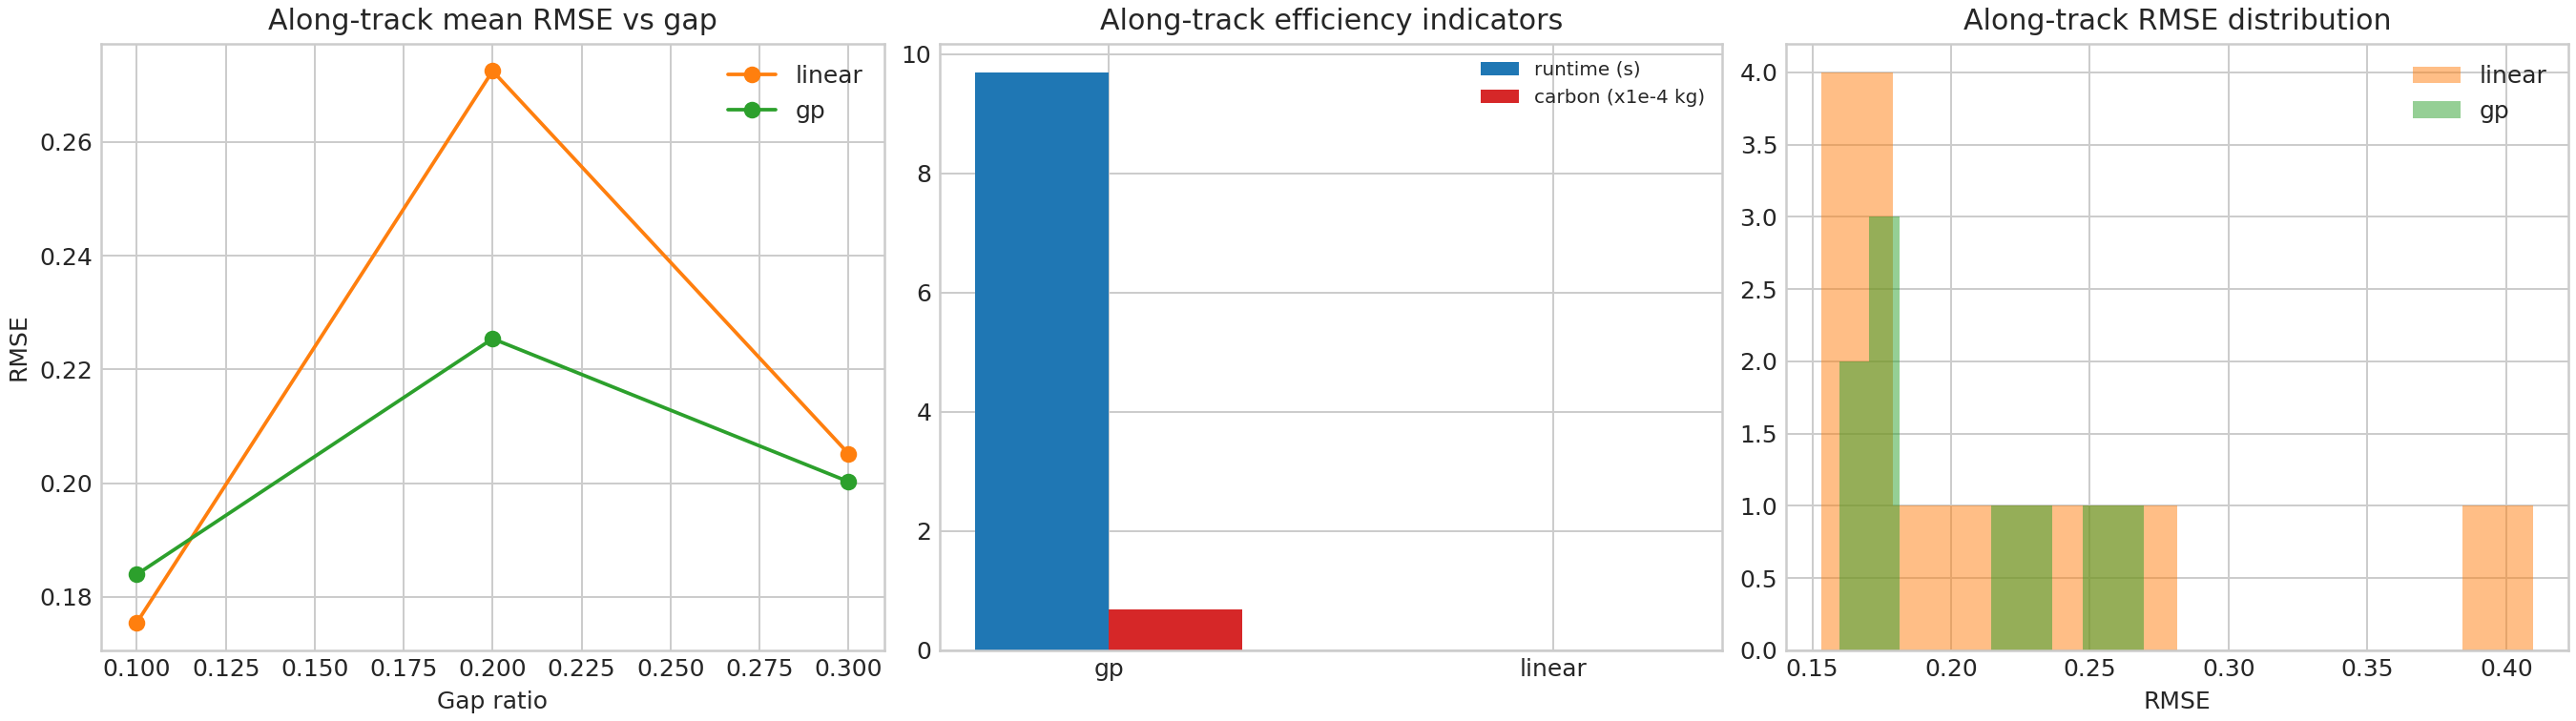

[PNG] /home/developer/ubuntu/project/ai/final/project/outputs/figures/alongtrack_reconstruction_best_gap20.png


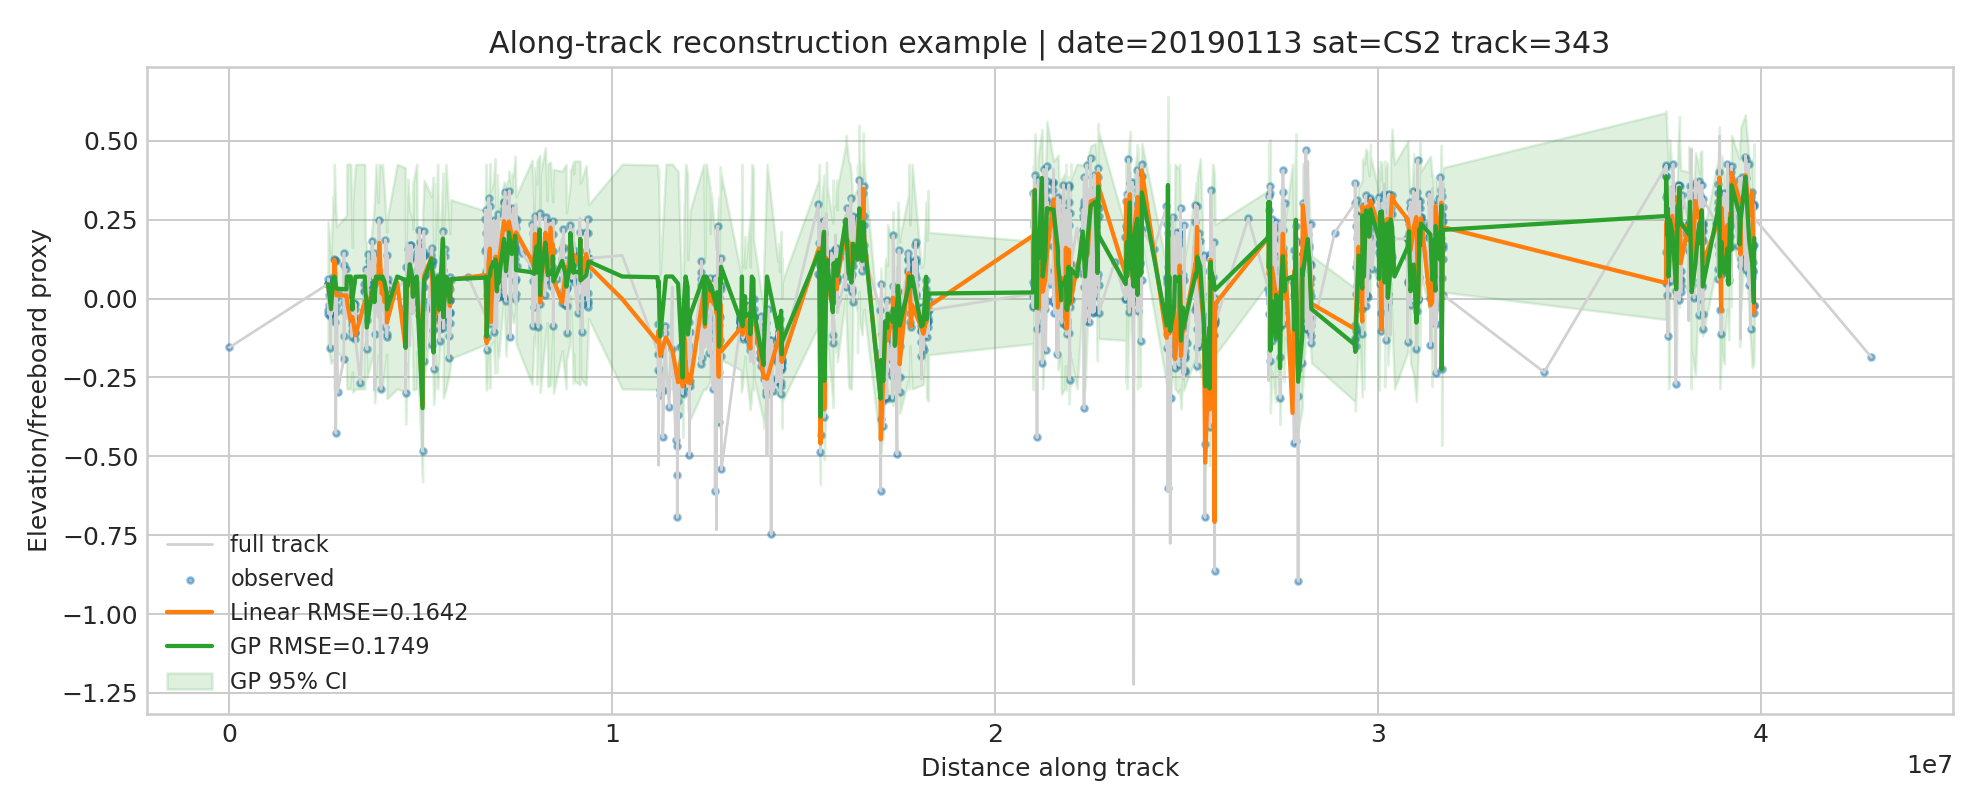

In [7]:
# Along-track visual summary
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

# RMSE by gap
for method, color in [('linear', 'tab:orange'), ('gp', 'tab:green')]:
    dd = along_df.groupby(['gap_ratio', 'method'])['rmse'].mean().reset_index()
    d = dd[dd['method'] == method]
    axes[0].plot(d['gap_ratio'], d['rmse'], marker='o', label=method, color=color)
axes[0].set_title('Along-track mean RMSE vs gap')
axes[0].set_xlabel('Gap ratio')
axes[0].set_ylabel('RMSE')
axes[0].legend()

# Runtime and carbon bars
agg = along_df.groupby('method')[['runtime_seconds', 'carbon_kg_co2e']].mean().reset_index()
x = np.arange(len(agg))
axes[1].bar(x - 0.15, agg['runtime_seconds'], width=0.3, label='runtime (s)', color='tab:blue')
axes[1].bar(x + 0.15, agg['carbon_kg_co2e'] * 1e4, width=0.3, label='carbon (x1e-4 kg)', color='tab:red')
axes[1].set_xticks(x)
axes[1].set_xticklabels(agg['method'])
axes[1].set_title('Along-track efficiency indicators')
axes[1].legend(fontsize=8)

# RMSE distribution across tracks and gaps
for method, color in [('linear', 'tab:orange'), ('gp', 'tab:green')]:
    vals = along_df[along_df['method'] == method]['rmse'].values
    axes[2].hist(vals, bins=10, alpha=0.5, label=method, color=color)
axes[2].set_title('Along-track RMSE distribution')
axes[2].set_xlabel('RMSE')
axes[2].legend()

fig.savefig(FIG_DIR / 'alongtrack_summary_dashboard.png', dpi=180)
plt.close(fig)

# reconstruction example: best GP run among gap=0.2
cand = along_df[(along_df['method'] == 'gp') & (along_df['gap_ratio'] == 0.2)].sort_values('rmse').iloc[0]
pk = (int(cand['date']), cand['sat'], int(cand['track']), float(cand['gap_ratio']))
p = along_predictions[pk]
order = np.argsort(p['s_test'])

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(p['s'], p['z'], color='0.82', lw=1.1, label='full track')
ax.scatter(p['s'][p['mask_train']], p['z'][p['mask_train']], s=6, alpha=0.45, color='tab:blue', label='observed')
ax.plot(p['s_test'][order], p['y_lin'][order], color='tab:orange', lw=1.7, label=f"Linear RMSE={p['lin_rmse']:.4f}")
ax.plot(p['s_test'][order], p['y_gp'][order], color='tab:green', lw=1.7, label=f"GP RMSE={p['gp_rmse']:.4f}")
ax.fill_between(
    p['s_test'][order],
    p['y_gp'][order] - 1.96 * p['y_gp_std'][order],
    p['y_gp'][order] + 1.96 * p['y_gp_std'][order],
    color='tab:green', alpha=0.15, label='GP 95% CI'
)
ax.set_title(f"Along-track reconstruction example | date={pk[0]} sat={pk[1]} track={pk[2]}")
ax.set_xlabel('Distance along track')
ax.set_ylabel('Elevation/freeboard proxy')
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'alongtrack_reconstruction_best_gap20.png', dpi=180)
plt.close(fig)

print('Saved along-track figures.')


display_png(FIG_DIR / 'alongtrack_summary_dashboard.png')
display_png(FIG_DIR / 'alongtrack_reconstruction_best_gap20.png')


## Spatial-Field Reconstruction Experiments

This stage tests interpolation on irregular 2D samples.
To balance realism and execution cost:
- LinearND and IDW are run on full split subsets,
- GP is run with capped train/test subsets for stable runtime.

Output of this stage:
- per-method/per-gap metrics table,
- a representative snapshot at gap=0.2 for direct visual comparison.

### Spatial-Field Experiment Execution

This step evaluates interpolation behavior over irregular 2D spatial samples.

- What is done: runs LinearND, IDW, and GP-subset under consistent missing-data ratios.
- How it is done: uses a shared split strategy and subset caps for GP to keep runtime practical.
- Why it matters next: provides quantitative evidence for cross-method spatial reconstruction quality.

In [8]:
grid_df = preds[['pred_loc_x', 'pred_loc_y', 'f*']].rename(columns={'f*': 'target'}).copy()
if len(grid_df) > 150000:
    grid_df = grid_df.sample(150000, random_state=SEED)

X = grid_df[['pred_loc_x', 'pred_loc_y']].to_numpy(float)
y = grid_df['target'].to_numpy(float)

grid_rows = []
run_snapshots = {}

for gap_ratio in [0.1, 0.2, 0.3]:
    n = len(X)
    n_test = int(n * gap_ratio)
    idx_test = rng.choice(np.arange(n), size=n_test, replace=False)
    mask_test = np.zeros(n, dtype=bool)
    mask_test[idx_test] = True
    mask_train = ~mask_test

    X_train, y_train = X[mask_train], y[mask_train]
    X_test, y_test = X[mask_test], y[mask_test]

    # LinearND
    t0 = time.perf_counter()
    linear = LinearNDInterpolator(X_train, y_train, fill_value=np.nan)
    y_lin = linear(X_test)
    nan_mask = np.isnan(y_lin)
    if np.any(nan_mask):
        nn = NearestNDInterpolator(X_train, y_train)
        y_lin[nan_mask] = nn(X_test[nan_mask])
    dt_lin = time.perf_counter() - t0

    # IDW via KNN distance weighting
    t1 = time.perf_counter()
    idw = KNeighborsRegressor(n_neighbors=8, weights='distance')
    idw.fit(X_train, y_train)
    y_idw = idw.predict(X_test)
    dt_idw = time.perf_counter() - t1

    # GP subset
    t2 = time.perf_counter()
    tr_cap, te_cap = 2500, 4000
    tr_idx = np.arange(len(X_train))
    te_idx = np.arange(len(X_test))
    if len(tr_idx) > tr_cap:
        tr_idx = rng.choice(tr_idx, size=tr_cap, replace=False)
    if len(te_idx) > te_cap:
        te_idx = rng.choice(te_idx, size=te_cap, replace=False)

    X_train_gp, y_train_gp = X_train[tr_idx], y_train[tr_idx]
    X_test_gp, y_test_gp = X_test[te_idx], y_test[te_idx]

    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=250000.0, length_scale_bounds=(1e3, 2e6)) + WhiteKernel(1e-4, (1e-7, 1e-1))
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=1, random_state=SEED)
    gp.fit(X_train_gp, y_train_gp)
    y_gp = gp.predict(X_test_gp)
    dt_gp = time.perf_counter() - t2

    m_lin = regression_metrics(y_test, y_lin)
    m_idw = regression_metrics(y_test, y_idw)
    m_gp = regression_metrics(y_test_gp, y_gp)

    grid_rows.append({'gap_ratio': gap_ratio, 'method': 'linearND', **m_lin, **estimate_environment_cost(dt_lin)})
    grid_rows.append({'gap_ratio': gap_ratio, 'method': 'idw_knn', **m_idw, **estimate_environment_cost(dt_idw)})
    grid_rows.append({'gap_ratio': gap_ratio, 'method': 'gp_subset', **m_gp, **estimate_environment_cost(dt_gp)})

    if abs(gap_ratio - 0.2) < 1e-9:
        keep = rng.choice(np.arange(len(X_test)), size=min(6000, len(X_test)), replace=False)
        run_snapshots['gap20'] = {
            'x': X_test[keep, 0],
            'y': X_test[keep, 1],
            'truth': y_test[keep],
            'linear': y_lin[keep],
            'idw': y_idw[keep],
        }

grid_df_metrics = pd.DataFrame(grid_rows)
grid_df_metrics.to_csv(MET_DIR / 'gridded_metrics.csv', index=False)
grid_df_metrics


display_csv_preview(MET_DIR / 'gridded_metrics.csv')


/home/developer/.local/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:429: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


/home/developer/.local/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:429: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


/home/developer/.local/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:429: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


[CSV] /home/developer/ubuntu/project/ai/final/project/outputs/metrics/gridded_metrics.csv | rows=9 cols=11


,gap_ratio,method,mae,rmse,r2,runtime_seconds,avg_power_watts,pue,carbon_intensity_g_per_kwh,energy_kwh,carbon_kg_co2e
0,0.1,linearND,0.014806,0.039662,0.759354,2.755976,45.0,1.2,475.0,0.000041,1.963633e-05
1,0.1,idw_knn,0.014191,0.035921,0.802615,0.101123,45.0,1.2,475.0,0.000002,7.205034e-07
2,0.1,gp_subset,0.015525,0.033313,0.829804,69.011604,45.0,1.2,475.0,0.001035,4.917077e-04
3,0.2,linearND,0.014453,0.038657,0.768599,2.879767,45.0,1.2,475.0,0.000043,2.051834e-05
4,0.2,idw_knn,0.013939,0.035196,0.808180,0.145479,45.0,1.2,475.0,0.000002,1.036536e-06
5,0.2,gp_subset,0.015447,0.034524,0.814817,79.704673,45.0,1.2,475.0,0.001196,5.678958e-04
6,0.3,linearND,0.014248,0.038202,0.775781,2.630411,45.0,1.2,475.0,0.000039,1.874168e-05
7,0.3,idw_knn,0.013781,0.034828,0.813633,0.163709,45.0,1.2,475.0,0.000002,1.166428e-06
8,0.3,gp_subset,0.014085,0.030976,0.845399,86.549252,45.0,1.2,475.0,0.001298,6.166634e-04


### Spatial-Field Comparison Visuals

This step turns spatial experiment outputs into comparative visuals.

- What is done: RMSE/MAE trends, accuracy-runtime/carbon trade-offs, and spatial reconstruction snapshots.
- How it is done: composes multi-panel figures using the same metric tables used for exports.
- Why it matters next: prepares the bridge from predictive accuracy to feature recoverability analysis.

Saved gridded figures.
[PNG] /home/developer/ubuntu/project/ai/final/project/outputs/figures/gridded_metrics_dashboard.png


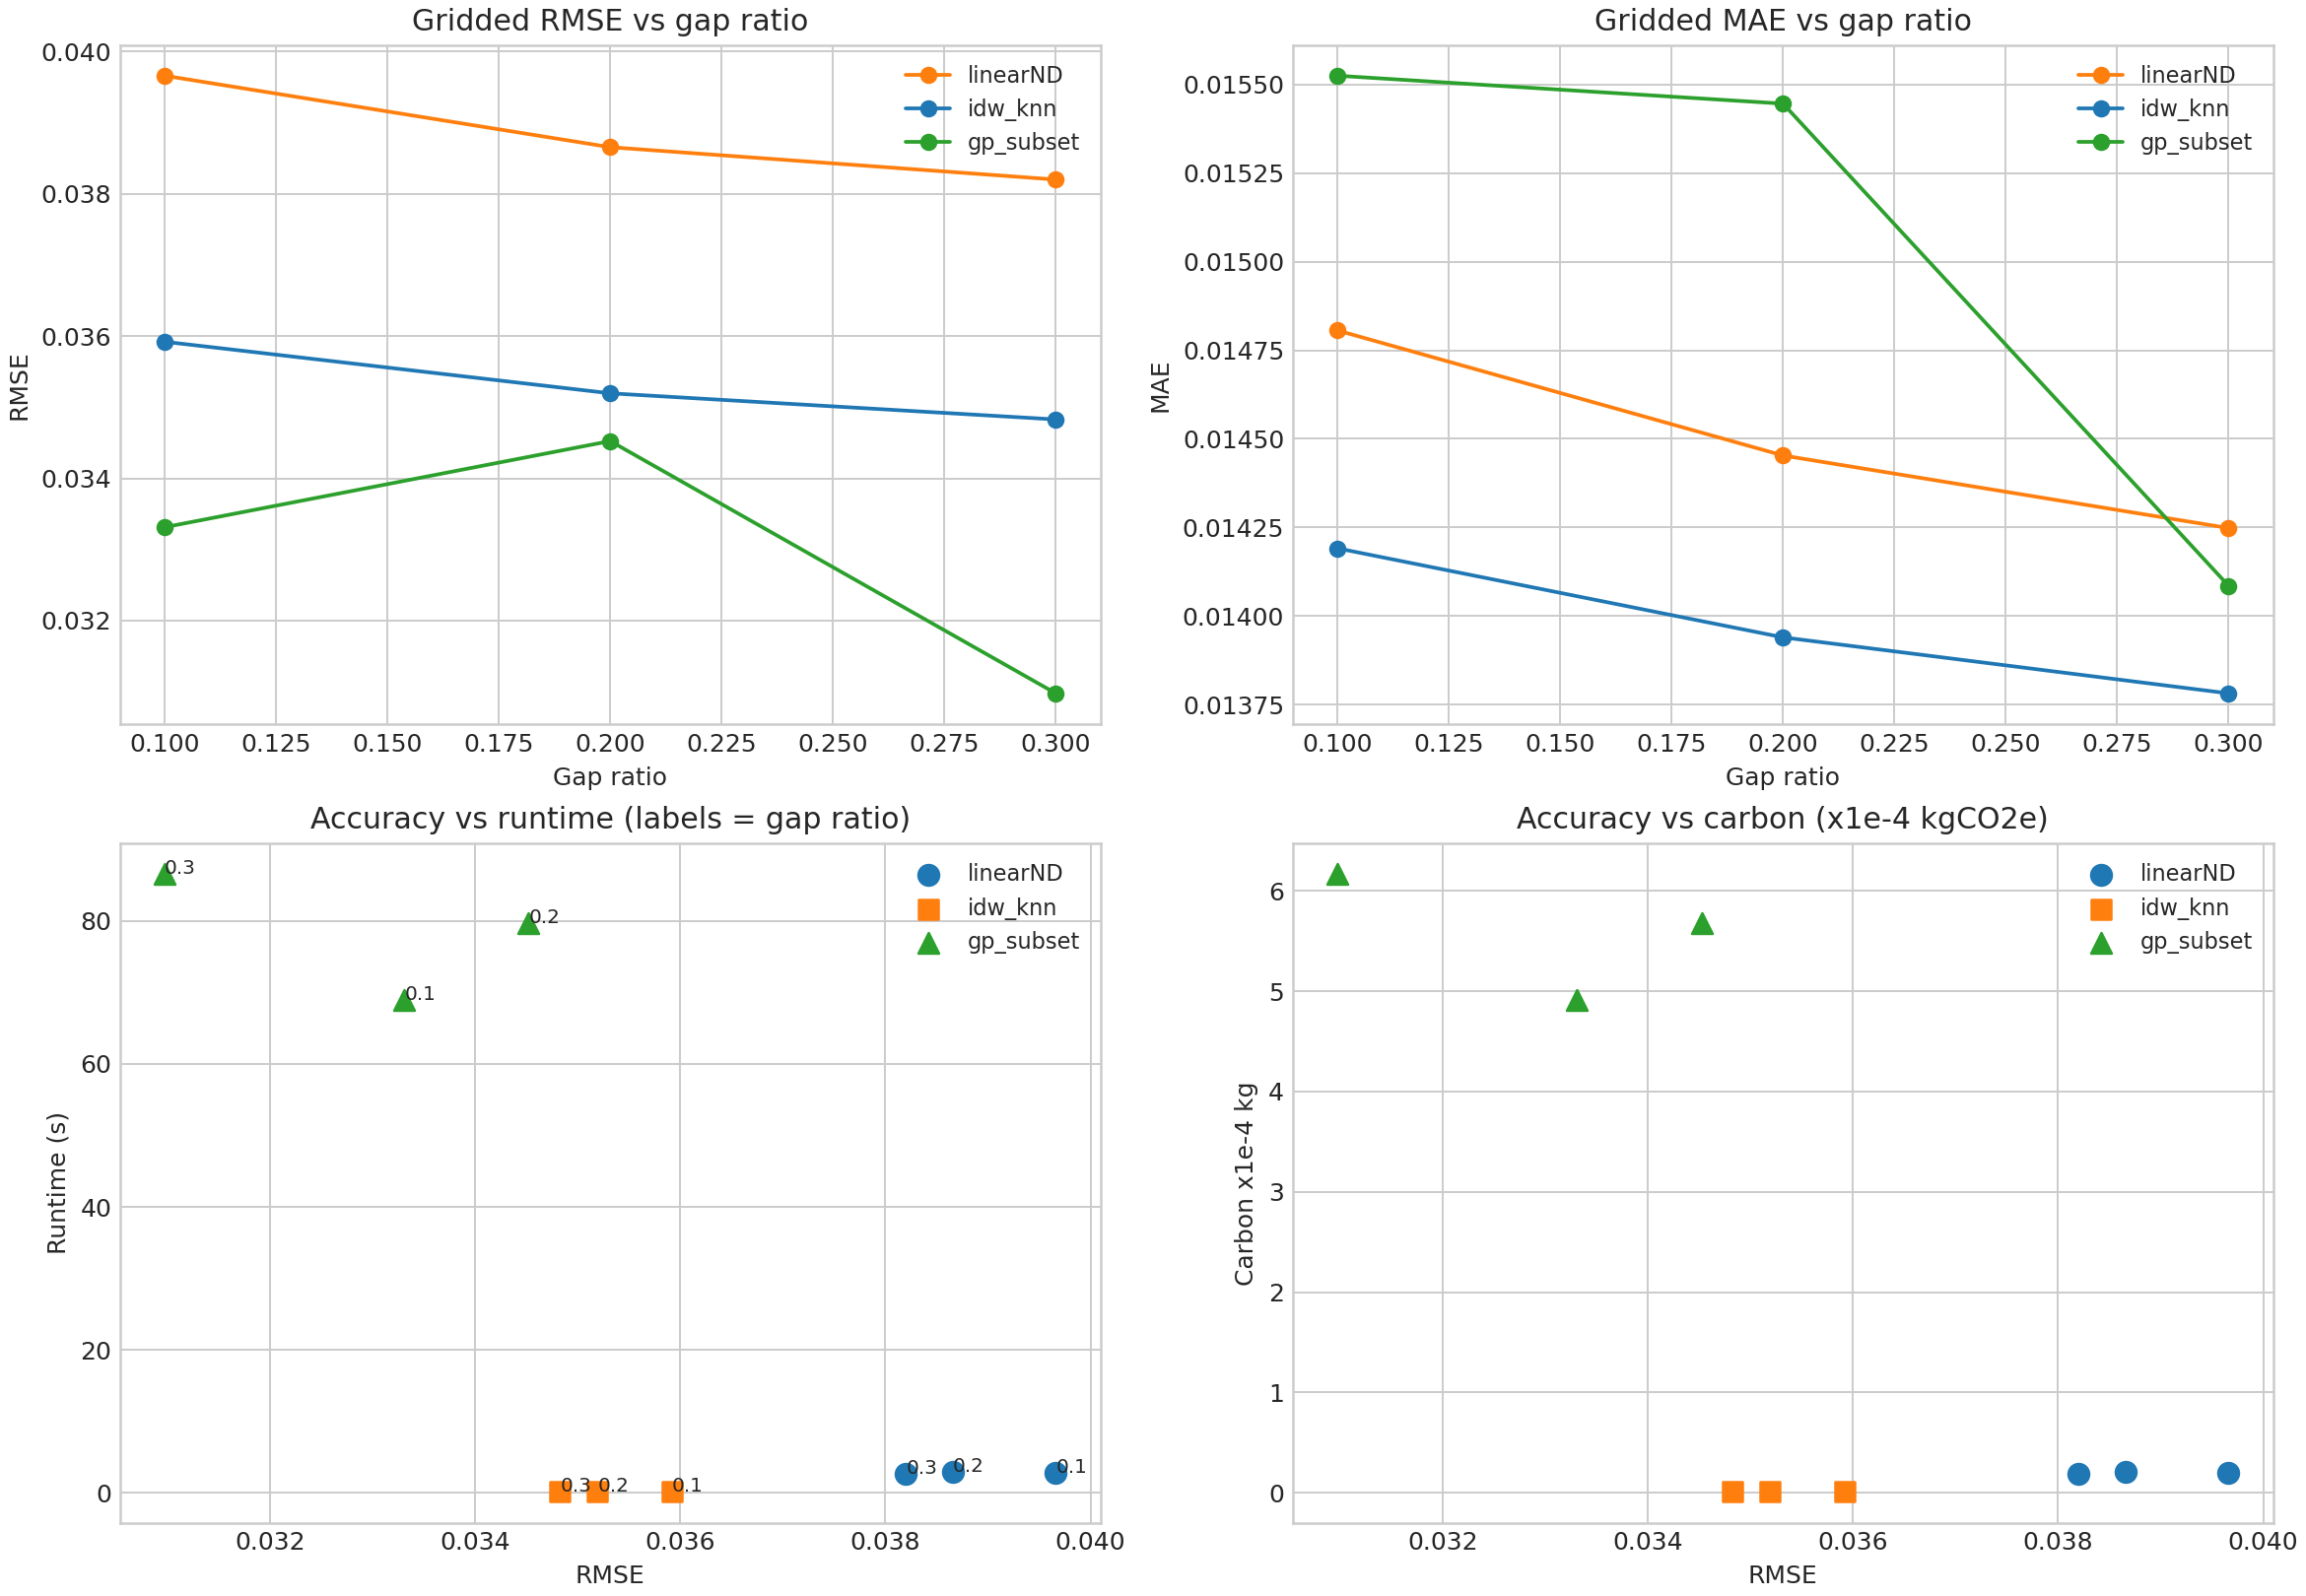

[PNG] /home/developer/ubuntu/project/ai/final/project/outputs/figures/gridded_spatial_reconstruction_gap20.png


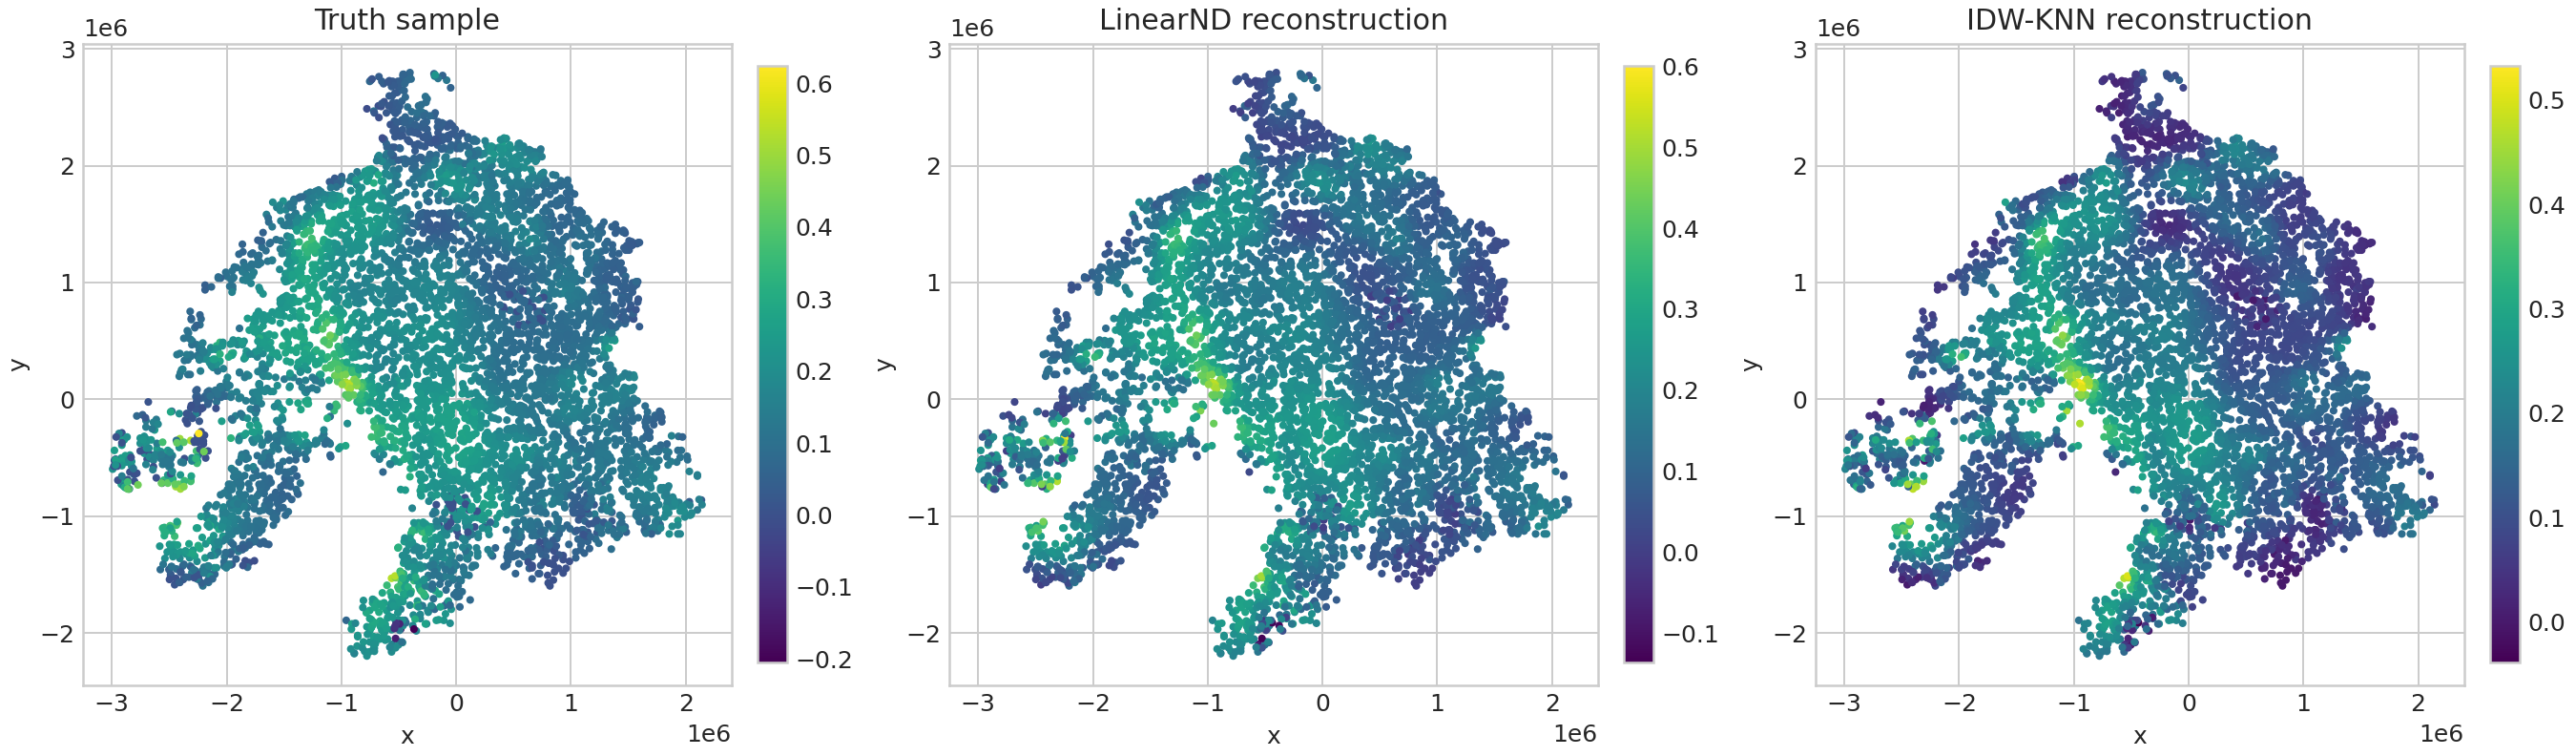

In [9]:
# Gridded visual diagnostics
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

# RMSE curves
for method, color in [('linearND', 'tab:orange'), ('idw_knn', 'tab:blue'), ('gp_subset', 'tab:green')]:
    d = grid_df_metrics[grid_df_metrics['method'] == method]
    axes[0, 0].plot(d['gap_ratio'], d['rmse'], marker='o', label=method, color=color)
axes[0, 0].set_title('Gridded RMSE vs gap ratio')
axes[0, 0].set_xlabel('Gap ratio')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].legend(fontsize=9)

# MAE curves
for method, color in [('linearND', 'tab:orange'), ('idw_knn', 'tab:blue'), ('gp_subset', 'tab:green')]:
    d = grid_df_metrics[grid_df_metrics['method'] == method]
    axes[0, 1].plot(d['gap_ratio'], d['mae'], marker='o', label=method, color=color)
axes[0, 1].set_title('Gridded MAE vs gap ratio')
axes[0, 1].set_xlabel('Gap ratio')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend(fontsize=9)

# Runtime trade-off
for method, marker in [('linearND', 'o'), ('idw_knn', 's'), ('gp_subset', '^')]:
    d = grid_df_metrics[grid_df_metrics['method'] == method]
    axes[1, 0].scatter(d['rmse'], d['runtime_seconds'], label=method, marker=marker, s=70)
    for _, r in d.iterrows():
        axes[1, 0].text(r['rmse'], r['runtime_seconds'], f"{r['gap_ratio']}", fontsize=8)
axes[1, 0].set_title('Accuracy vs runtime (labels = gap ratio)')
axes[1, 0].set_xlabel('RMSE')
axes[1, 0].set_ylabel('Runtime (s)')
axes[1, 0].legend(fontsize=9)

# Carbon trade-off
for method, marker in [('linearND', 'o'), ('idw_knn', 's'), ('gp_subset', '^')]:
    d = grid_df_metrics[grid_df_metrics['method'] == method]
    axes[1, 1].scatter(d['rmse'], d['carbon_kg_co2e'] * 1e4, label=method, marker=marker, s=70)
axes[1, 1].set_title('Accuracy vs carbon (x1e-4 kgCO2e)')
axes[1, 1].set_xlabel('RMSE')
axes[1, 1].set_ylabel('Carbon x1e-4 kg')
axes[1, 1].legend(fontsize=9)

fig.savefig(FIG_DIR / 'gridded_metrics_dashboard.png', dpi=180)
plt.close(fig)

# Spatial comparison snapshot at gap=0.2
p = run_snapshots['gap20']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
for ax, key, title in [
    (axes[0], 'truth', 'Truth sample'),
    (axes[1], 'linear', 'LinearND reconstruction'),
    (axes[2], 'idw', 'IDW-KNN reconstruction'),
]:
    sc = ax.scatter(p['x'], p['y'], c=p[key], s=5, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
fig.savefig(FIG_DIR / 'gridded_spatial_reconstruction_gap20.png', dpi=180)
plt.close(fig)

print('Saved gridded figures.')


display_png(FIG_DIR / 'gridded_metrics_dashboard.png')
display_png(FIG_DIR / 'gridded_spatial_reconstruction_gap20.png')


## Unresolved Feature Potential Assessment

Prediction error alone is not enough; we also check whether reconstruction recovers informative structure.

Two proxy analyses are performed:
- **Spatial recoverability**: edge sharpness, feature count, and mesoscale spectral-band recovery.
- **Temporal recoverability**: variance, lag-1 autocorrelation, and band-power recovery.

These analyses are framed as recovery toward a denser reference signal.

### Spatial Recoverability Analysis

This step asks whether reconstruction preserves physically meaningful spatial structure.

- What is done: compares sparse reference vs reconstructed field against a denser reference tile.
- How it is done: computes edge sharpness, feature-count behavior, and mesoscale spectral-band recovery.
- Why it matters next: adds structural validity evidence beyond pointwise error metrics.

[PNG] /home/developer/ubuntu/project/ai/final/project/outputs/figures/spatial_feature_gain.png


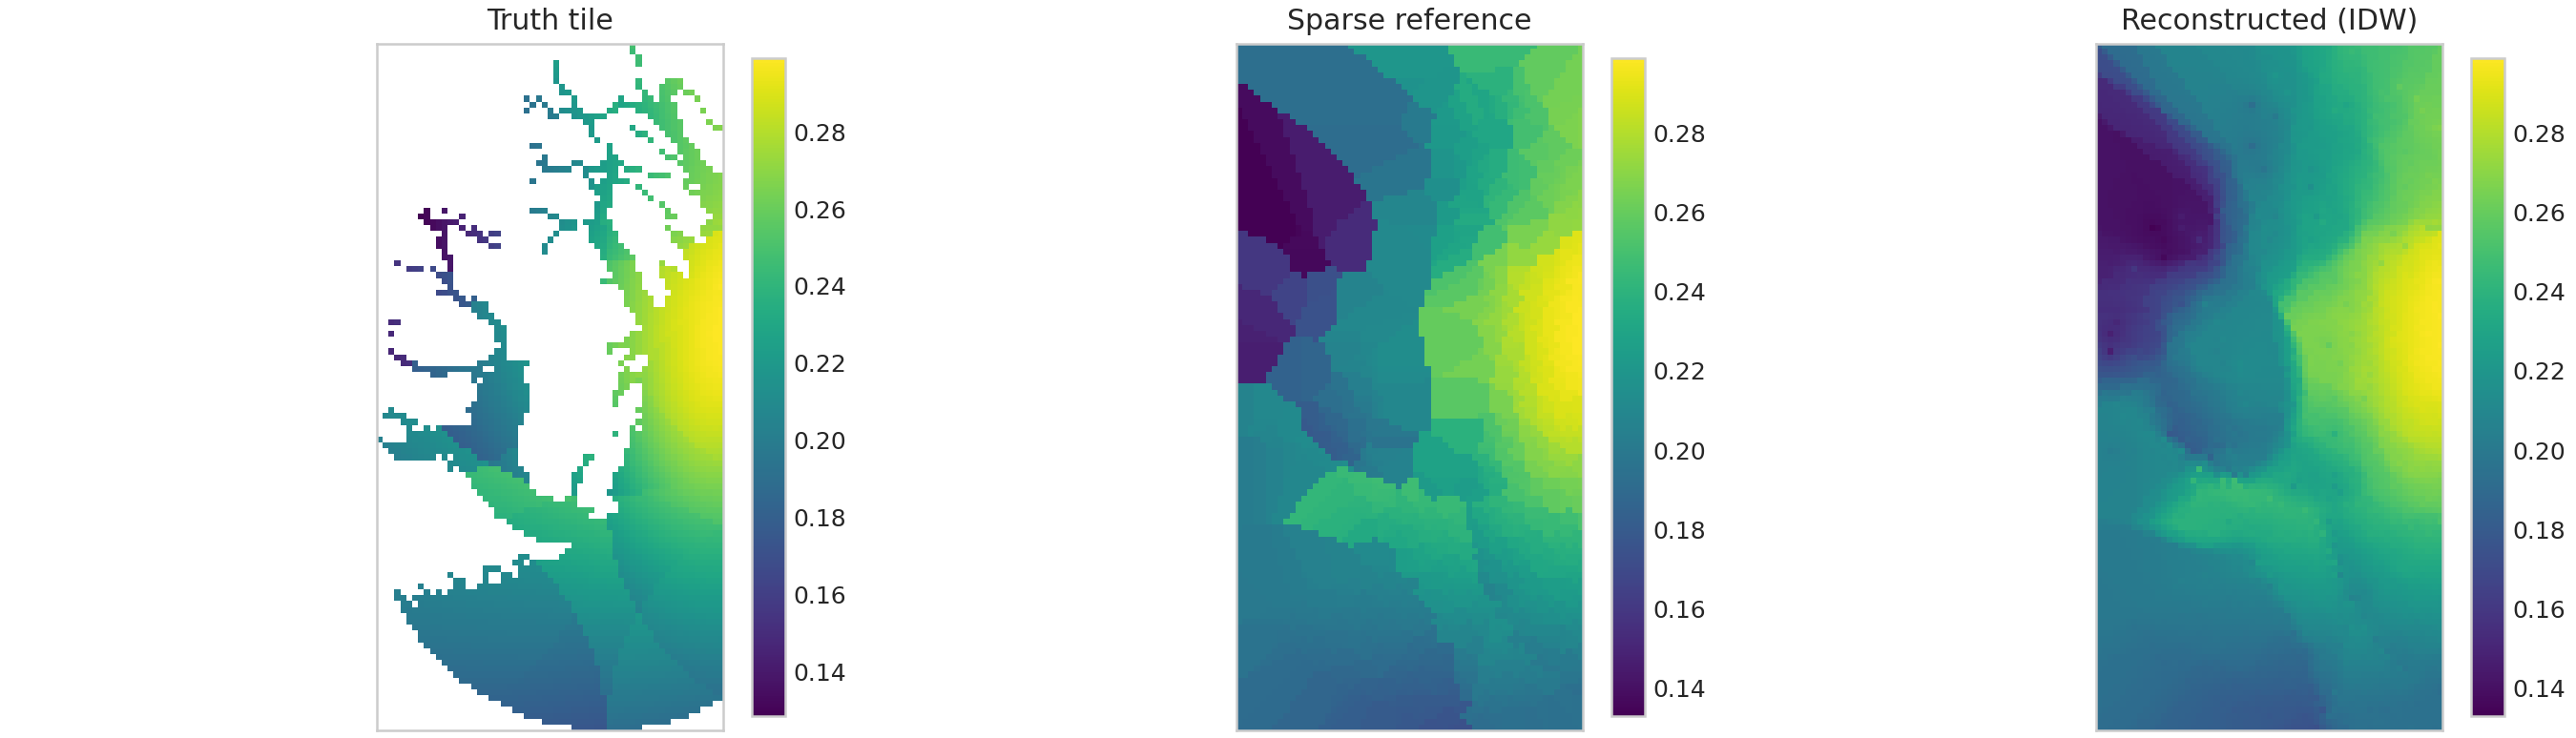

[CSV] /home/developer/ubuntu/project/ai/final/project/outputs/metrics/spatial_feature_gain.csv | rows=1 cols=12


,feature_count_truth,feature_count_sparse,feature_count_reconstructed,feature_recovery_gain,edge_sharpness_truth,edge_sharpness_sparse,edge_sharpness_reconstructed,edge_recovery_gain,psd_band_truth,psd_band_sparse,psd_band_reconstructed,psd_recovery_gain
0,0,20,18,1.111111,0.002585,0.00307,0.00263,10.946967,3.4568,6.138936,4.630949,2.284322


In [10]:
# Spatial feature potential
sp = preds[['pred_loc_x', 'pred_loc_y', 'f*']].rename(columns={'f*': 'target'}).dropna()

x_lo, x_hi = -1400000.0, -700000.0
y_lo, y_hi = -2200000.0, -1500000.0
tile = sp[(sp['pred_loc_x'].between(x_lo, x_hi)) & (sp['pred_loc_y'].between(y_lo, y_hi))].copy()
if len(tile) < 5000:
    tile = sp.sample(20000, random_state=SEED).copy()

pivot = tile.pivot_table(index='pred_loc_y', columns='pred_loc_x', values='target', aggfunc='mean').sort_index().sort_index(axis=1)
truth = pivot.to_numpy(float)

mask_obs = rng.random(truth.shape) < 0.30
sparse = np.where(mask_obs, truth, np.nan)

obs_y, obs_x = np.where(np.isfinite(sparse))
obs_vals = sparse[np.isfinite(sparse)]
all_y, all_x = np.indices(truth.shape)
pts_obs = np.column_stack([obs_x, obs_y])
pts_all = np.column_stack([all_x.ravel(), all_y.ravel()])

nn = KNeighborsRegressor(n_neighbors=1, weights='uniform')
nn.fit(pts_obs, obs_vals)
sparse_fill = nn.predict(pts_all).reshape(truth.shape)

idw = KNeighborsRegressor(n_neighbors=8, weights='distance')
idw.fit(pts_obs, obs_vals)
recon = idw.predict(pts_all).reshape(truth.shape)


def edge_sharpness(a):
    gy, gx = np.gradient(a)
    return float(np.nanmean(np.sqrt(gx*gx + gy*gy)))


def feature_count(a):
    hp = gaussian_filter(a, 1.2) - gaussian_filter(a, 3.5)
    mx = maximum_filter(hp, size=5)
    peaks = (hp == mx) & (hp > np.nanpercentile(hp, 92))
    return int(np.sum(peaks))

truth_edge = edge_sharpness(truth)
sparse_edge = edge_sharpness(sparse_fill)
recon_edge = edge_sharpness(recon)

truth_feat = feature_count(truth)
sparse_feat = feature_count(sparse_fill)
recon_feat = feature_count(recon)

truth_psd = radial_band_power(truth)
sparse_psd = radial_band_power(sparse_fill)
recon_psd = radial_band_power(recon)

spatial_gain = {
    'feature_count_truth': truth_feat,
    'feature_count_sparse': sparse_feat,
    'feature_count_reconstructed': recon_feat,
    'feature_recovery_gain': float((abs(sparse_feat - truth_feat) + 1e-12) / (abs(recon_feat - truth_feat) + 1e-12)),
    'edge_sharpness_truth': truth_edge,
    'edge_sharpness_sparse': sparse_edge,
    'edge_sharpness_reconstructed': recon_edge,
    'edge_recovery_gain': float((abs(sparse_edge - truth_edge) + 1e-12) / (abs(recon_edge - truth_edge) + 1e-12)),
    'psd_band_truth': truth_psd,
    'psd_band_sparse': sparse_psd,
    'psd_band_reconstructed': recon_psd,
    'psd_recovery_gain': float((abs(sparse_psd - truth_psd) + 1e-12) / (abs(recon_psd - truth_psd) + 1e-12)),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)
for ax, arr, title in [
    (axes[0], truth, 'Truth tile'),
    (axes[1], sparse_fill, 'Sparse reference'),
    (axes[2], recon, 'Reconstructed (IDW)'),
]:
    im = ax.imshow(arr, cmap='viridis', origin='lower')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.savefig(FIG_DIR / 'spatial_feature_gain.png', dpi=180)
plt.close(fig)

pd.DataFrame([spatial_gain]).to_csv(MET_DIR / 'spatial_feature_gain.csv', index=False)
pd.DataFrame([spatial_gain])


display_png(FIG_DIR / 'spatial_feature_gain.png')
display_csv_preview(MET_DIR / 'spatial_feature_gain.csv')


### Temporal Recoverability Analysis

This step evaluates recovery of short-timescale temporal variability proxies.

- What is done: compares full signal, sparse reference signal, and reconstructed signal.
- How it is done: reports variance, lag-1 autocorrelation, and frequency-band recovery metrics.
- Why it matters next: complements spatial structure checks with temporal behavior consistency.

[PNG] /home/developer/ubuntu/project/ai/final/project/outputs/figures/temporal_variability_gain.png


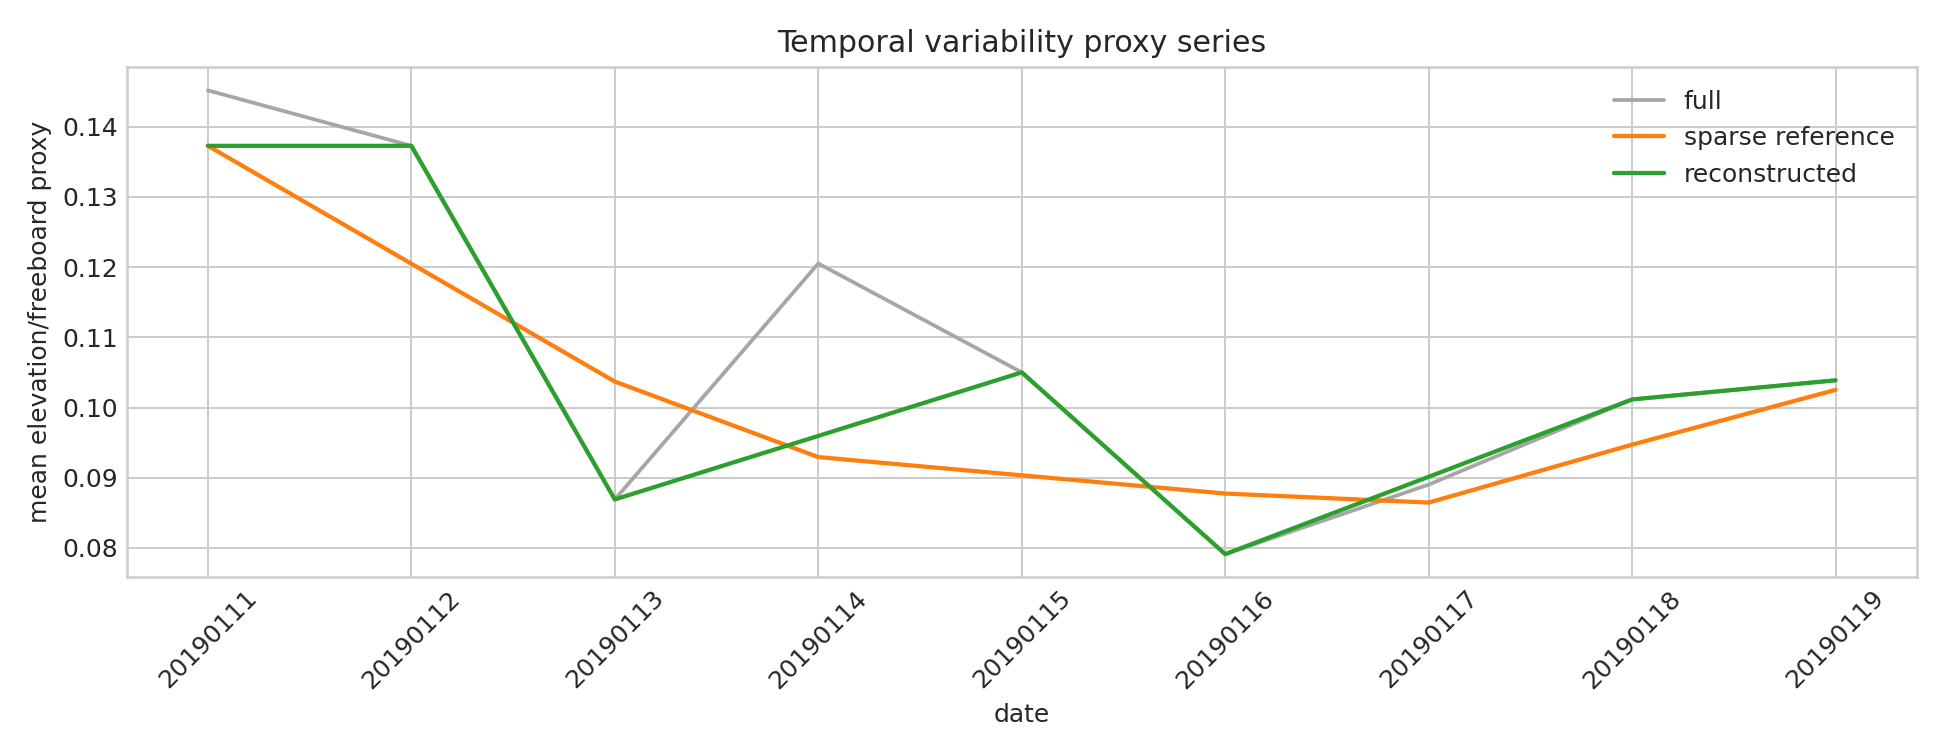

[CSV] /home/developer/ubuntu/project/ai/final/project/outputs/metrics/temporal_variability_gain.csv | rows=1 cols=12


,variance_full,variance_sparse,variance_reconstructed,variance_recovery_gain,lag1_full,lag1_sparse,lag1_reconstructed,lag1_recovery_gain,band_power_full,band_power_sparse,band_power_reconstructed,band_power_recovery_gain
0,0.000456,0.000256,0.000377,2.522428,0.300191,0.880616,0.381589,7.130651,0.005957,0.003306,0.005074,3.000561


In [11]:
# Temporal feature potential
region = df_gpod[(df_gpod['lat'] >= 70.0) & (df_gpod['x'].between(-1500000, 1500000)) & (df_gpod['y'].between(-1500000, 1500000))]
series_full = region.groupby('date')['elevation'].mean().sort_index()

series_sparse = series_full.copy()
series_sparse.iloc[np.arange(0, len(series_sparse), 3)] = np.nan
series_sparse_reference = series_sparse.ffill().bfill().rolling(3, min_periods=1, center=True).mean()
series_recon = series_sparse.interpolate(method='linear').ffill().bfill()


def lag1_autocorr(s):
    x = np.asarray(s, dtype=float)
    x0 = x[:-1] - np.mean(x[:-1])
    x1 = x[1:] - np.mean(x[1:])
    denom = np.sqrt(np.sum(x0*x0) * np.sum(x1*x1))
    return float(np.sum(x0*x1) / denom) if denom > 0 else float('nan')


def band_power_1d(s, low=0.1, high=0.4):
    x = np.asarray(s, dtype=float)
    x = x - np.mean(x)
    F = np.fft.rfft(x)
    P = np.abs(F) ** 2
    f = np.fft.rfftfreq(len(x), d=1.0)
    m = (f >= low) & (f <= high)
    return float(P[m].mean()) if np.any(m) else float('nan')

var_full, var_sparse, var_recon = float(np.var(series_full)), float(np.var(series_sparse_reference)), float(np.var(series_recon))
lag_full, lag_sparse, lag_recon = lag1_autocorr(series_full), lag1_autocorr(series_sparse_reference), lag1_autocorr(series_recon)
bp_full, bp_sparse, bp_recon = band_power_1d(series_full), band_power_1d(series_sparse_reference), band_power_1d(series_recon)

temporal_gain = {
    'variance_full': var_full,
    'variance_sparse': var_sparse,
    'variance_reconstructed': var_recon,
    'variance_recovery_gain': float((abs(var_sparse - var_full) + 1e-12) / (abs(var_recon - var_full) + 1e-12)),
    'lag1_full': lag_full,
    'lag1_sparse': lag_sparse,
    'lag1_reconstructed': lag_recon,
    'lag1_recovery_gain': float((abs(lag_sparse - lag_full) + 1e-12) / (abs(lag_recon - lag_full) + 1e-12)),
    'band_power_full': bp_full,
    'band_power_sparse': bp_sparse,
    'band_power_reconstructed': bp_recon,
    'band_power_recovery_gain': float((abs(bp_sparse - bp_full) + 1e-12) / (abs(bp_recon - bp_full) + 1e-12)),
}

fig, ax = plt.subplots(figsize=(10.8, 4.2))
ax.plot(series_full.index.astype(str), series_full.values, lw=1.5, color='0.65', label='full')
ax.plot(series_sparse_reference.index.astype(str), series_sparse_reference.values, lw=1.7, color='tab:orange', label='sparse reference')
ax.plot(series_recon.index.astype(str), series_recon.values, lw=1.7, color='tab:green', label='reconstructed')
ax.set_title('Temporal variability proxy series')
ax.set_xlabel('date')
ax.set_ylabel('mean elevation/freeboard proxy')
ax.tick_params(axis='x', labelrotation=45)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'temporal_variability_gain.png', dpi=180)
plt.close(fig)

pd.DataFrame([temporal_gain]).to_csv(MET_DIR / 'temporal_variability_gain.csv', index=False)
pd.DataFrame([temporal_gain])


display_png(FIG_DIR / 'temporal_variability_gain.png')
display_csv_preview(MET_DIR / 'temporal_variability_gain.csv')


## Environmental Cost Assessment and Trade-offs

This section aggregates all experiment records to answer method-comparison questions:
- Which methods are accurate but computationally heavy?
- Which methods provide a better accuracy-runtime-carbon balance?

It also creates a scenario-style comparison for contextual carbon interpretation.

### Aggregate Trade-Off and Environmental Comparison

This step combines all experiment records into cross-method comparisons.

- What is done: merges trajectory and spatial metrics and plots accuracy-runtime-carbon trade-offs.
- How it is done: method-level aggregates are exported as summary tables.
- Why it matters next: supports balanced methodological selection rather than metric-only ranking.

[PNG] /home/developer/ubuntu/project/ai/final/project/outputs/figures/accuracy_runtime_carbon_tradeoff.png


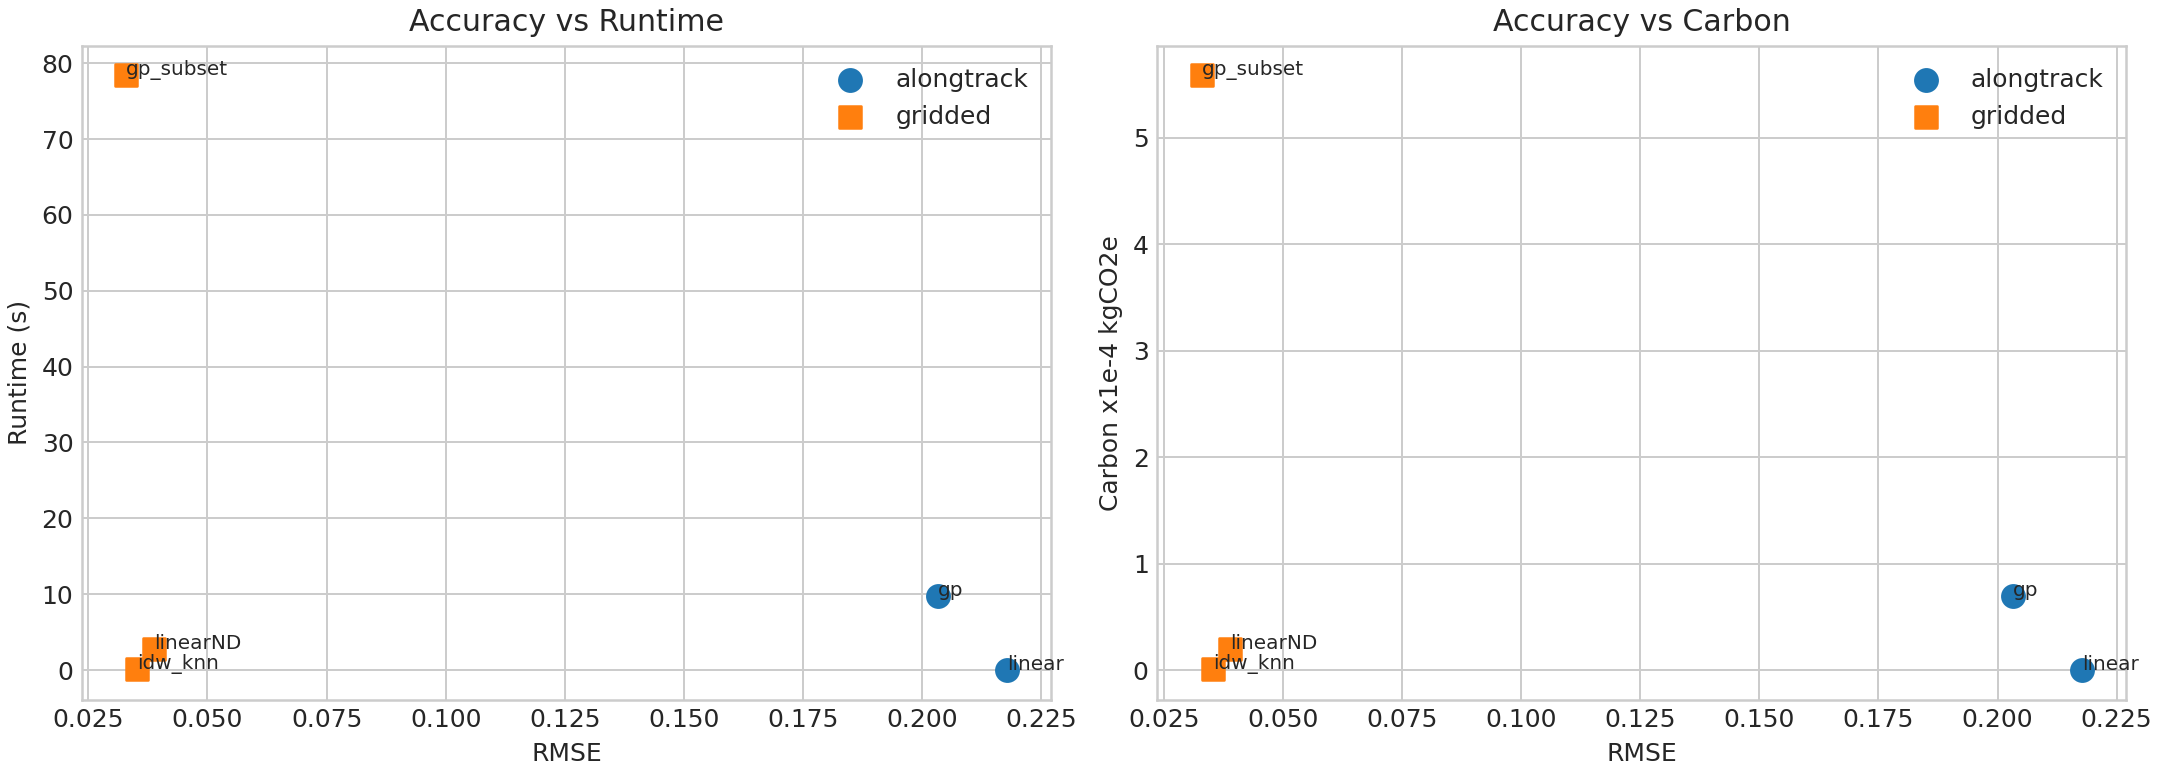

[CSV] /home/developer/ubuntu/project/ai/final/project/outputs/tables/method_tradeoff_summary.csv | rows=5 cols=6


,scope,method,rmse,runtime_seconds,energy_kwh,carbon_kg_co2e
0,alongtrack,gp,0.203224,9.695282,1.454292e-04,6.907888e-05
1,alongtrack,linear,0.217730,0.000040,5.986967e-10,2.843809e-10
2,gridded,gp_subset,0.032938,78.421843,1.176328e-03,5.587556e-04
3,gridded,idw_knn,0.035315,0.136770,2.051556e-06,9.744890e-07
4,gridded,linearND,0.038840,2.755385,4.133077e-05,1.963212e-05


[CSV] /home/developer/ubuntu/project/ai/final/project/outputs/tables/environment_scenario_comparison.csv | rows=3 cols=2


,scenario,carbon_kg_co2e
0,ml_pipeline_runs,0.002360
1,field_campaign_reference,1500.000000
2,relative_reduction_percent,99.999843


[CSV] /home/developer/ubuntu/project/ai/final/project/outputs/metrics/all_method_metrics.csv | rows=27 cols=16
Showing first 20 rows (table is larger).


,date,sat,track,gap_ratio,n_points,method,mae,rmse,r2,runtime_seconds,avg_power_watts,pue,carbon_intensity_g_per_kwh,energy_kwh,carbon_kg_co2e,scope
0,20190115.0,CS2,393.0,0.1,2400.0,linear,0.113708,0.164870,0.244946,0.000036,45.0,1.2,475.0,5.445300e-10,2.586517e-10,alongtrack
1,20190115.0,CS2,393.0,0.1,2400.0,gp,0.129729,0.177626,0.123592,6.715544,45.0,1.2,475.0,1.007332e-04,4.784825e-05,alongtrack
2,20190115.0,CS2,393.0,0.2,2400.0,linear,0.137158,0.409769,-1.150177,0.000037,45.0,1.2,475.0,5.490300e-10,2.607892e-10,alongtrack
3,20190115.0,CS2,393.0,0.2,2400.0,gp,0.154840,0.269385,0.070730,11.104299,45.0,1.2,475.0,1.665645e-04,7.911813e-05,alongtrack
4,20190115.0,CS2,393.0,0.3,2400.0,linear,0.121205,0.259428,-0.014126,0.000031,45.0,1.2,475.0,4.650300e-10,2.208893e-10,alongtrack
5,20190115.0,CS2,393.0,0.3,2400.0,gp,0.169328,0.257645,-0.000237,4.890656,45.0,1.2,475.0,7.335985e-05,3.484593e-05,alongtrack
6,20190113.0,CS2,343.0,0.1,2400.0,linear,0.110221,0.153377,0.351331,0.000061,45.0,1.2,475.0,9.075450e-10,4.310839e-10,alongtrack
7,20190113.0,CS2,343.0,0.1,2400.0,gp,0.117886,0.159630,0.297364,5.519054,45.0,1.2,475.0,8.278580e-05,3.932326e-05,alongtrack
8,20190113.0,CS2,343.0,0.2,2400.0,linear,0.111569,0.164184,0.234628,0.000029,45.0,1.2,475.0,4.335000e-10,2.059125e-10,alongtrack
9,20190113.0,CS2,343.0,0.2,2400.0,gp,0.122245,0.174933,0.131125,16.699787,45.0,1.2,475.0,2.504968e-04,1.189860e-04,alongtrack


In [12]:
all_metrics = pd.concat([
    along_df.assign(scope='alongtrack'),
    grid_df_metrics.assign(scope='gridded'),
], ignore_index=True)
all_metrics.to_csv(MET_DIR / 'all_method_metrics.csv', index=False)

agg = all_metrics.groupby(['scope', 'method'], as_index=False)[['rmse', 'runtime_seconds', 'energy_kwh', 'carbon_kg_co2e']].mean()
agg.to_csv(TAB_DIR / 'method_tradeoff_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), constrained_layout=True)
for scope, marker in [('alongtrack', 'o'), ('gridded', 's')]:
    d = agg[agg['scope'] == scope]
    axes[0].scatter(d['rmse'], d['runtime_seconds'], s=80, marker=marker, label=scope)
    for _, r in d.iterrows():
        axes[0].text(r['rmse'], r['runtime_seconds'], r['method'], fontsize=8)
axes[0].set_title('Accuracy vs Runtime')
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('Runtime (s)')
axes[0].legend()

for scope, marker in [('alongtrack', 'o'), ('gridded', 's')]:
    d = agg[agg['scope'] == scope]
    axes[1].scatter(d['rmse'], d['carbon_kg_co2e'] * 1e4, s=80, marker=marker, label=scope)
    for _, r in d.iterrows():
        axes[1].text(r['rmse'], r['carbon_kg_co2e'] * 1e4, r['method'], fontsize=8)
axes[1].set_title('Accuracy vs Carbon')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('Carbon x1e-4 kgCO2e')
axes[1].legend()

fig.savefig(FIG_DIR / 'accuracy_runtime_carbon_tradeoff.png', dpi=180)
plt.close(fig)

# reference scenario comparison
field_campaign_kg = 1500.0
pipeline_kg = float(all_metrics['carbon_kg_co2e'].sum())
reduction = 100.0 * (1.0 - pipeline_kg / field_campaign_kg)

env_summary = pd.DataFrame([
    {'scenario': 'ml_pipeline_runs', 'carbon_kg_co2e': pipeline_kg},
    {'scenario': 'field_campaign_reference', 'carbon_kg_co2e': field_campaign_kg},
    {'scenario': 'relative_reduction_percent', 'carbon_kg_co2e': reduction},
])
env_summary.to_csv(TAB_DIR / 'environment_scenario_comparison.csv', index=False)

env_summary


display_png(FIG_DIR / 'accuracy_runtime_carbon_tradeoff.png')
display_csv_preview(TAB_DIR / 'method_tradeoff_summary.csv')
display_csv_preview(TAB_DIR / 'environment_scenario_comparison.csv')
display_csv_preview(MET_DIR / 'all_method_metrics.csv')


## Discussion

### Key Findings
- Spatial-field reconstruction reaches lower RMSE in this setup, consistent with smoother target-field characteristics.
- IDW remains robust and efficient across tested missing-data settings.
- GP provides uncertainty-aware predictions with a higher compute budget.
- Recovery diagnostics indicate improved structural recoverability versus sparse references.

### Limitations
- Spatial reference field is model-derived (`/preds`) rather than direct raw truth.
- GP uses subset caps for runtime feasibility.
- Temporal recoverability relies on regional mean proxies.

### Next Steps
- add spatial block cross-validation,
- include independent external validation datasets,
- extend recoverability metrics with additional physics-informed diagnostics.

## Export Final Report Artifacts

Final export cell responsibilities:
- write compact machine-readable summary metrics,
- persist aggregate outputs used by downstream reporting,
- keep the notebook self-contained for handoff and reproducibility.

### Final Artifact Export

This closing step writes compact machine-readable outputs for handoff.

- What is done: exports summary JSON and confirms final artifact paths.
- How it is done: packages key outcomes from prediction, recoverability, and environmental sections.
- Why it matters: keeps the notebook usable as a reproducible external deliverable.

In [13]:
summary = {
    'alongtrack_best_rmse': float(along_df['rmse'].min()),
    'gridded_best_rmse': float(grid_df_metrics['rmse'].min()),
    'spatial_gain': spatial_gain,
    'temporal_gain': temporal_gain,
    'environment_total_carbon_kg': float(all_metrics['carbon_kg_co2e'].sum()),
}

with open(MET_DIR / 'summary_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('Summary metrics exported to outputs/metrics/summary_metrics.json')
summary


print('[JSON] outputs/metrics/summary_metrics.json')
print(json.dumps(summary, ensure_ascii=False, indent=2))


Summary metrics exported to outputs/metrics/summary_metrics.json
[JSON] outputs/metrics/summary_metrics.json
{
  "alongtrack_best_rmse": 0.1533771652973775,
  "gridded_best_rmse": 0.030975923992941617,
  "spatial_gain": {
    "feature_count_truth": 0,
    "feature_count_sparse": 20,
    "feature_count_reconstructed": 18,
    "feature_recovery_gain": 1.111111111111105,
    "edge_sharpness_truth": 0.002585188107016919,
    "edge_sharpness_sparse": 0.0030704535579857595,
    "edge_sharpness_reconstructed": 0.002629516862649939,
    "edge_recovery_gain": 10.946967359950108,
    "psd_band_truth": 3.4567995570828534,
    "psd_band_sparse": 6.1389360082566515,
    "psd_band_reconstructed": 4.630949290377488,
    "psd_recovery_gain": 2.2843223271417923
  },
  "temporal_gain": {
    "variance_full": 0.0004561677789510306,
    "variance_sparse": 0.0002560109974383572,
    "variance_reconstructed": 0.00037681694900396035,
    "variance_recovery_gain": 2.522428311383216,
    "lag1_full": 0.3001908